# Supplementary: Checking spe-1 patch recordings for a stimulation artifact

**Ashley's comment:** the spe-1 dataset is described as spontaneous activity, but we can't formally rule out that the experimenter delivered stimulation at some points to drive low-firing neurons. Her suggestion for what to look for: *"I think you would see this as a very slight shift in membrane potential unless they had balanced the bridge absolutely perfectly ... you might also see tiny capacitance transients."*

**What this notebook does:** for every spe-1 cell, using the **raw, unfiltered** patch recording (not the bandpass-filtered version used elsewhere in the paper, since filtering can hide a slow baseline shift), find real changes in the resting membrane potential and check whether they line up with real changes in spike waveform shape, the signature a genuine shift in Vm would leave (a current step doesn't explain a change in spike shape; voltage-dependent channel kinetics do). We didn't end up systematically checking for capacitance transients, a sustained current strong enough to change a cell's firing would already show up as the sustained baseline shift checked here, so that's the more direct test.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sys.path.append('../../datasets/spe-1/spe1_helper_modules/')
import config
from stim_artifact_check import (
    compute_baseline, get_pelt_changepoints, bin_ordinal,
    load_cluster_df, waveform_cluster_columns, load_or_compute,
    plot_baseline_vs_cluster_example, plot_shift_summary_funnel, strip_cluster, cluster_mix_after,
    compute_all_baseline_changepoints, compute_all_cluster_changepoints,
    ORDINAL_MAP, WAVEFORM_FEATURES, CLUST_COLORS,
)

CACHE_DIR = 'stim_artifact_check_cache'
FORCE_RERUN = False   # set True to recompute the slow steps and overwrite the cached pickles

# House plotting style (PLOTTING_GUIDELINES.md), sized up from the guideline defaults since
# these figures get viewed at reduced size in a supp PDF
sns.set_style('ticks')
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 150,
})

## Does the baseline level shift anywhere during the recording?

For each cell: split the raw recording into 1-second chunks and take the median voltage in each chunk (the median is barely affected by the handful of tall, brief spikes in each chunk, so this line tracks the *resting* level, not the spikes). A steady, if noisy, flat line means no shift. A step up or down to a new sustained level would be exactly the kind of "slight shift in membrane potential" Ashley described.

In [2]:
cell_nums = sorted(int(c[1:]) for c in config.CELL_IDS)
baselines = load_or_compute(os.path.join(CACHE_DIR, 'baselines.pkl'),
                             lambda: {cn: compute_baseline(cn) for cn in cell_nums},
                             force=FORCE_RERUN)

print(f'Computed baseline traces for {len(baselines)} cells.')

  [cache] baselines.pkl
Computed baseline traces for 43 cells.


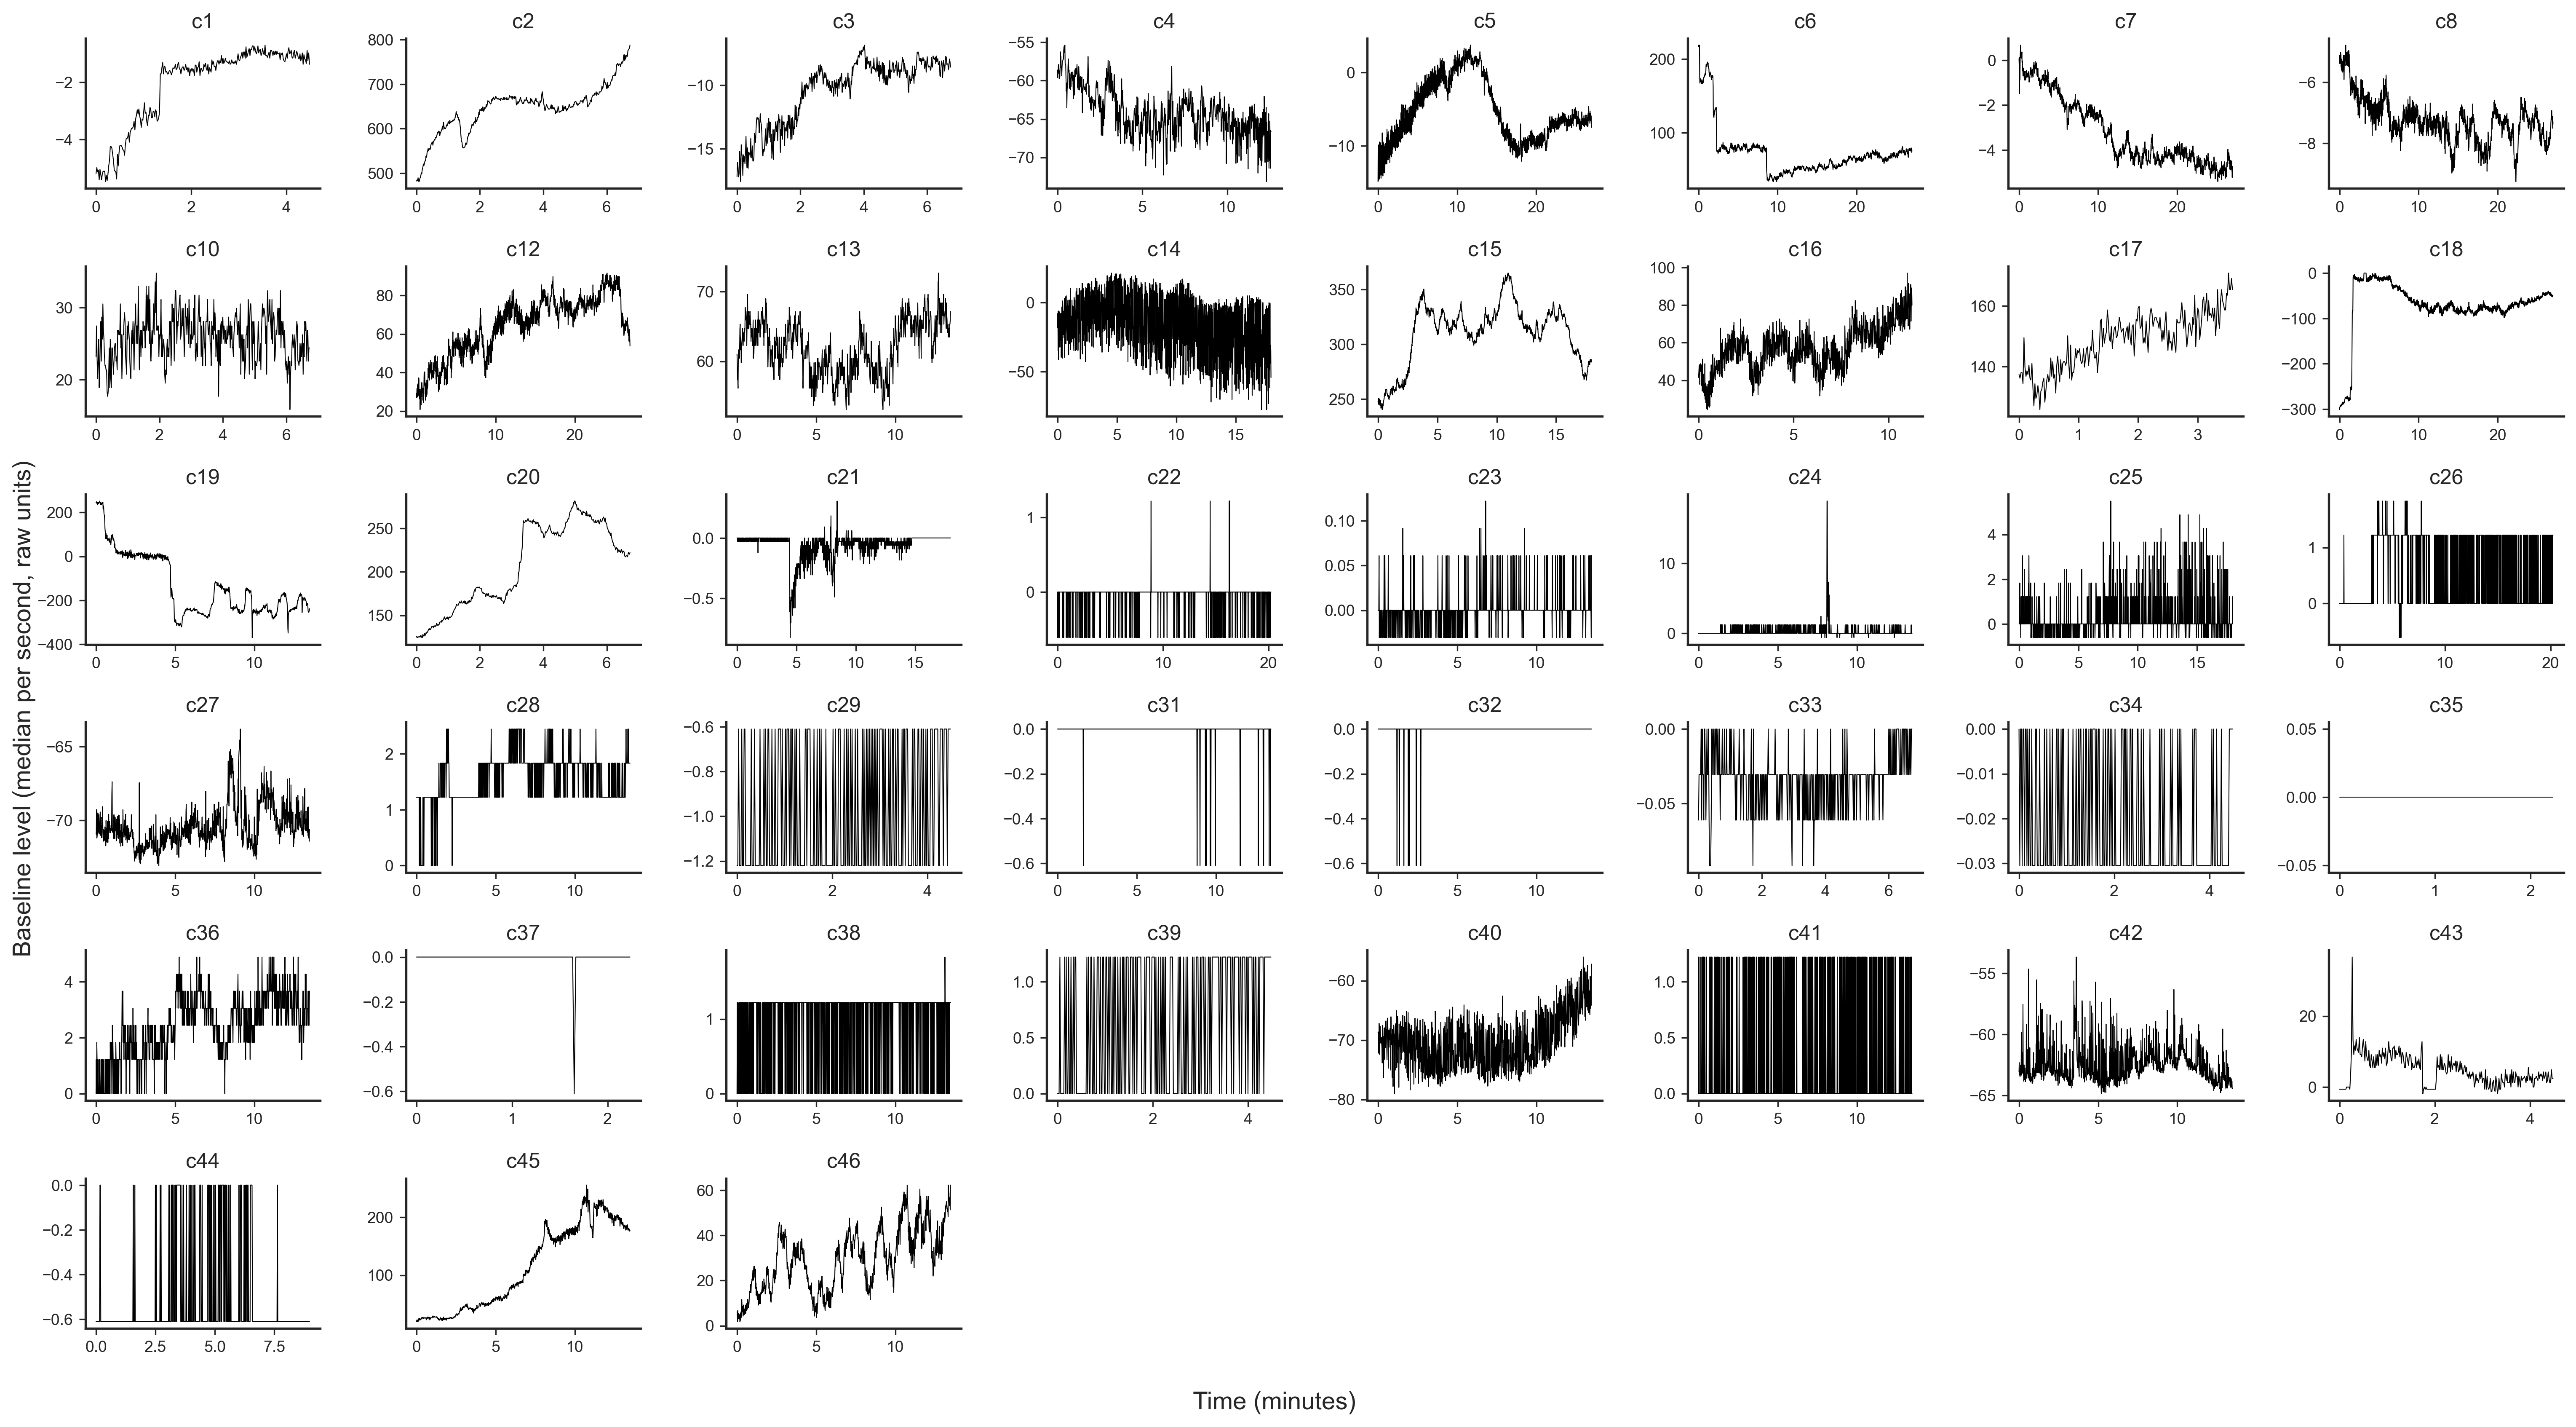

In [3]:
n = len(cell_nums)
ncols = 8
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 1.9))
axes = axes.flatten()

for ax, cell_num in zip(axes, cell_nums):
    t_min, baseline = baselines[cell_num]
    ax.plot(t_min, baseline, color='black', lw=0.5)
    ax.set_title(f'c{cell_num}', fontsize=12)
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)

for ax in axes[n:]:
    ax.axis('off')

fig.supxlabel('Time (minutes)', fontsize=14)
fig.supylabel('Baseline level (median per second, raw units)', fontsize=14)
plt.tight_layout()
plt.show()

### Finding real changes in the baseline, automatically

Instead of eyeballing 43 plots or hand rolling a jump-ratio rule, use PELT (Pruned Exact Linear Time), the standard changepoint-detection method, directly on each cell's per-second baseline. It finds every point where the mean level actually shifts, with a BIC-style penalty so it doesn't just chop the trace into noise-sized pieces.

In [4]:
baseline_changepoints = load_or_compute(os.path.join(CACHE_DIR, 'baseline_changepoints.pkl'),
                                         lambda: compute_all_baseline_changepoints(cell_nums, baselines),
                                         force=FORCE_RERUN)

print(f'{len(baseline_changepoints)} cells have a usable baseline, PELT changepoints found for '
      f'{sum(len(v) > 0 for v in baseline_changepoints.values())} of them.')

  [cache] baseline_changepoints.pkl
29 cells have a usable baseline, PELT changepoints found for 28 of them.


### Do baseline changes line up with waveform-cluster changes?

The pipeline's existing `find_temporal_transitions` table is too sparse for this, it only fits a sigmoid when one clears a quality threshold, so plenty of cells with an obvious cluster change (by eye) aren't in it at all. Do this directly instead: for every cell, take each waveform feature that got clustered into low/mid/high (`peak_amp_cluster`, `peak_width_cluster`, `peak_sharpness_cluster`), turn it into a 0/1/2 signal over time, bin it the same way as the baseline, and run PELT on that too. Same method, same rigor, applied to both signals, so they're directly comparable.

In [5]:
cluster_changepoints = load_or_compute(os.path.join(CACHE_DIR, 'cluster_changepoints.pkl'),
                                        lambda: compute_all_cluster_changepoints(cell_nums, baselines),
                                        force=FORCE_RERUN)

print(f'{len(cluster_changepoints)} cells have at least one clustered waveform-shape feature with a real changepoint.')

  [cache] cluster_changepoints.pkl
30 cells have at least one clustered waveform-shape feature with a real changepoint.


In [6]:
real_dists = []
dist_meta = []
for cid, feat_cps in cluster_changepoints.items():
    bcps = np.array(baseline_changepoints.get(cid, []))
    if len(bcps) == 0:
        continue
    for feat, cps in feat_cps.items():
        for cp in cps:
            real_dists.append(np.min(np.abs(bcps - cp)))
            dist_meta.append((cid, feat, cp))

real_dists = np.array(real_dists)
print(f'{len(real_dists)} cluster changepoints (across {len(set(m[0] for m in dist_meta))} cells) have a baseline '
      f'changepoint to compare against.')
print(f'Median distance to nearest baseline changepoint: {np.median(real_dists):.2f} min')
print(f'Mean distance: {real_dists.mean():.2f} min')

112 cluster changepoints (across 21 cells) have a baseline changepoint to compare against.
Median distance to nearest baseline changepoint: 1.00 min
Mean distance: 1.89 min


In [7]:
rng = np.random.default_rng(0)
N_SHUFFLE = 2000
durations_min = {f'c{cn}': baselines[cn][0][-1] for cn in cell_nums}

null_medians = np.empty(N_SHUFFLE)
null_means = np.empty(N_SHUFFLE)
for i in range(N_SHUFFLE):
    shuf = np.empty(len(real_dists))
    for j, (cid, feat, cp) in enumerate(dist_meta):
        bcps = np.array(baseline_changepoints[cid])
        t_shuf = rng.uniform(0, durations_min[cid])
        shuf[j] = np.min(np.abs(bcps - t_shuf))
    null_medians[i] = np.median(shuf)
    null_means[i] = shuf.mean()

print(f'Real median: {np.median(real_dists):.2f} min vs. chance {null_medians.mean():.2f} min '
      f'(p = {(null_medians <= np.median(real_dists)).mean():.4f})')
print(f'Real mean: {real_dists.mean():.2f} min vs. chance {null_means.mean():.2f} min '
      f'(p = {(null_means <= real_dists.mean()).mean():.4f})')

Real median: 1.00 min vs. chance 1.29 min (p = 0.0290)
Real mean: 1.89 min vs. chance 1.88 min (p = 0.5380)


### Quantifying it properly: which features, how many, clean switch or not

"Some cells overlap" isn't specific enough. For every cell that has at least one clustered waveform feature, check each of its features individually: did that feature actually get a changepoint, does it land near the baseline changepoint, and if so does the cell still show a mix of clusters afterward or a clean switch to one. That answers three things at once: which features carry the effect, whether it's usually all of a cell's features moving together or just some of them, and how often the "shift" is really just added variability rather than a full switch.

In [8]:
OVERLAP_TOL_MIN = 1.0

overlap_rows = []
for cell_num in cell_nums:
    cid = f'c{cell_num}'
    df = load_cluster_df(cell_num)
    if df is None:
        continue
    bcps = np.array(baseline_changepoints.get(cid, []))
    feat_cps = cluster_changepoints.get(cid, {})
    for feat in waveform_cluster_columns(df):
        cps = feat_cps.get(feat, [])
        has_changepoint = len(cps) > 0
        overlaps, still_mixed = False, np.nan
        if has_changepoint and len(bcps) > 0:
            dists = [np.min(np.abs(bcps - cp)) for cp in cps]
            best_cp = cps[int(np.argmin(dists))]
            overlaps = min(dists) <= OVERLAP_TOL_MIN
            if overlaps:
                props = cluster_mix_after(df, feat, best_cp)
                if props is not None:
                    still_mixed = (props > 0.10).sum() > 1
        overlap_rows.append({
            'cell_id': cid,
            'feature': feat.replace('_cluster', ''),
            'has_changepoint': has_changepoint,
            'overlaps_baseline': overlaps,
            'still_mixed': still_mixed,
        })

feature_overlap_df = pd.DataFrame(overlap_rows)
print(f'{len(feature_overlap_df)} (cell, feature) pairs across {feature_overlap_df.cell_id.nunique()} cells with '
      f'at least one clustered waveform feature.')
feature_overlap_df.head(10)

60 (cell, feature) pairs across 32 cells with at least one clustered waveform feature.


,cell_id,feature,has_changepoint,overlaps_baseline,still_mixed
0,c1,peak_amp,True,True,False
1,c1,peak_sharpness,True,True,False
2,c1,exp_lambda,True,True,True
3,c2,exp_lambda,False,False,NaN
4,c3,peak_amp,True,True,False
5,c4,peak_amp,True,True,False
6,c5,inflection_time,True,True,True
7,c5,inflection_amp,True,True,True
8,c5,peak_amp,True,True,True
9,c5,peak_width,True,True,True


**Headline numbers first:** of the cells with a real baseline shift, how many also show a waveform-shape shift, and of those, how many still look variable afterward rather than cleanly switching, then which specific features carry that effect.

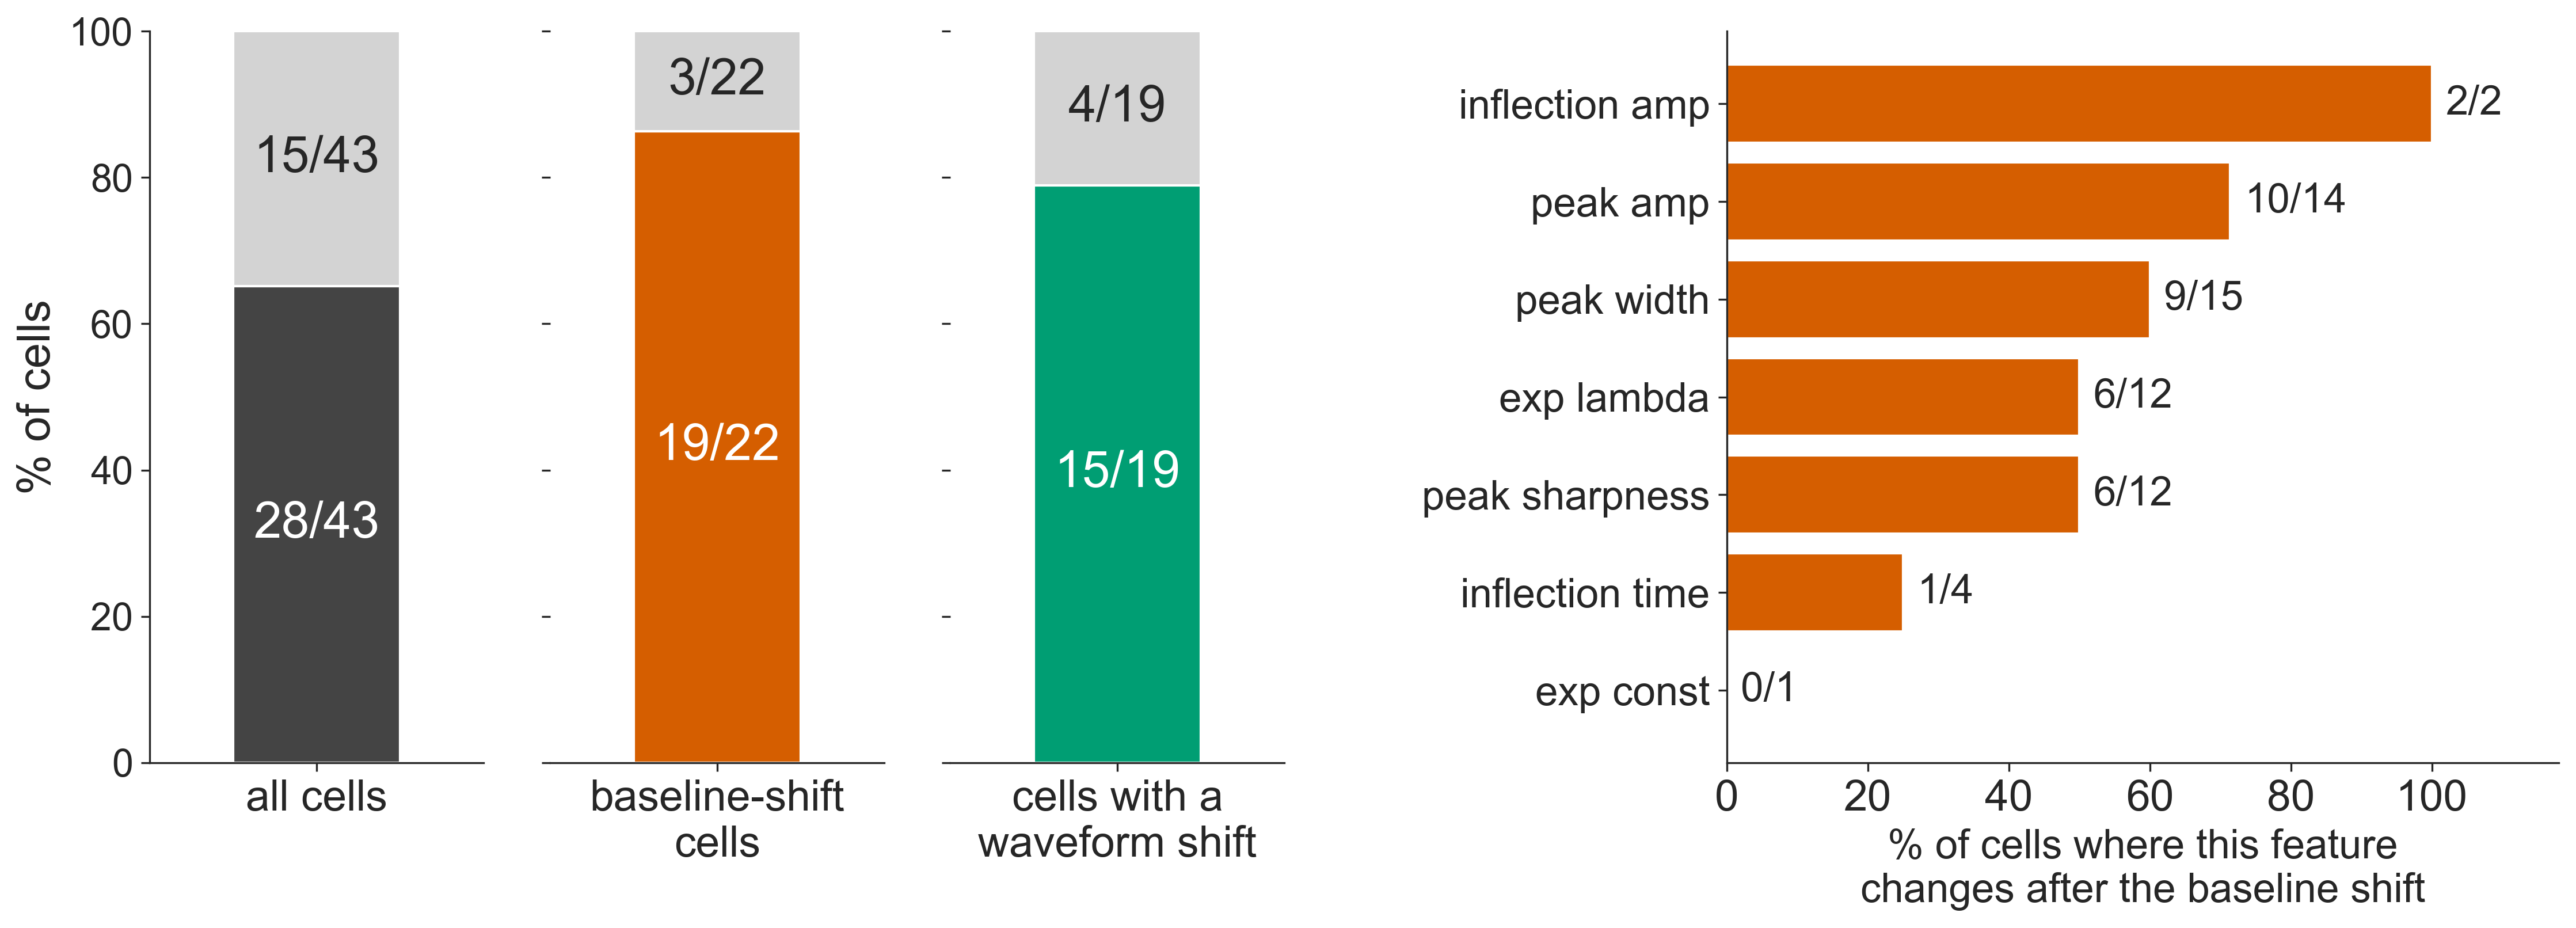

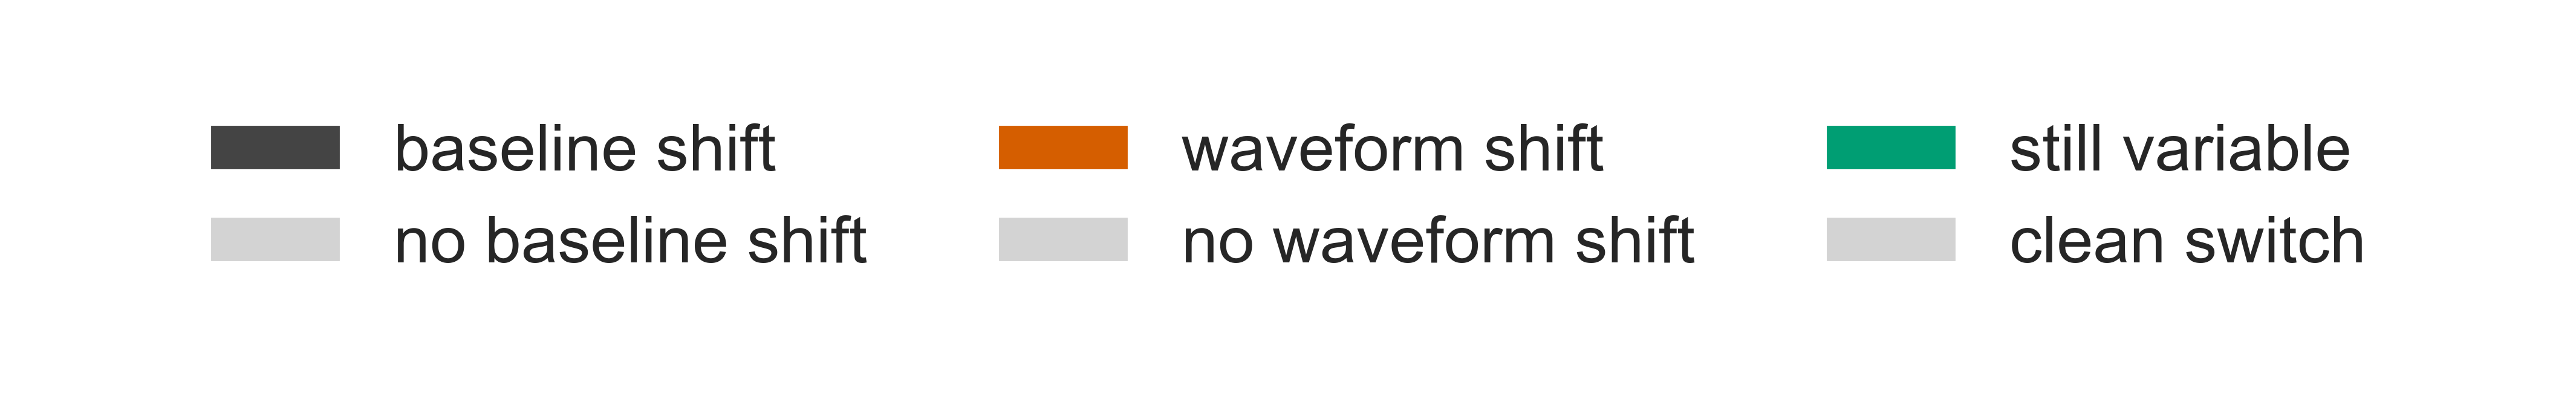

28/43 cells (65%) show a real baseline membrane potential shift.
19/22 baseline-shift cells (86%) also show a waveform-shape shift.
Of those, 15/19 (79%) still show more than one cluster afterward.


,feature,n_cells,n_overlapping,pct_overlapping
2,inflection_amp,2,2,100.0
4,peak_amp,14,10,71.4
6,peak_width,15,9,60.0
1,exp_lambda,12,6,50.0
5,peak_sharpness,12,6,50.0
3,inflection_time,4,1,25.0
0,exp_const,1,0,0.0


In [9]:
fig, fig_legend, stats = plot_shift_summary_funnel(cell_nums, baseline_changepoints, feature_overlap_df)
display(fig)
display(fig_legend)
plt.close(fig)
plt.close(fig_legend)

print(f'{stats["n_baseline_shift"]}/{stats["n_total"]} cells ({stats["pct_baseline_shift"]:.0f}%) show a real '
      f'baseline membrane potential shift.')
print(f'{stats["n_shift"]}/{stats["n_checkable"]} baseline-shift cells ({stats["pct_shift"]:.0f}%) also show a '
      f'waveform-shape shift.')
print(f'Of those, {stats["n_mixed"]}/{stats["n_with_shift"]} ({stats["pct_mixed"]:.0f}%) still show more than '
      f'one cluster afterward.')
stats['feat_summary']

**By cell:** when a cell has more than one clustered waveform feature, does the baseline shift show up in all of them, or just a subset?

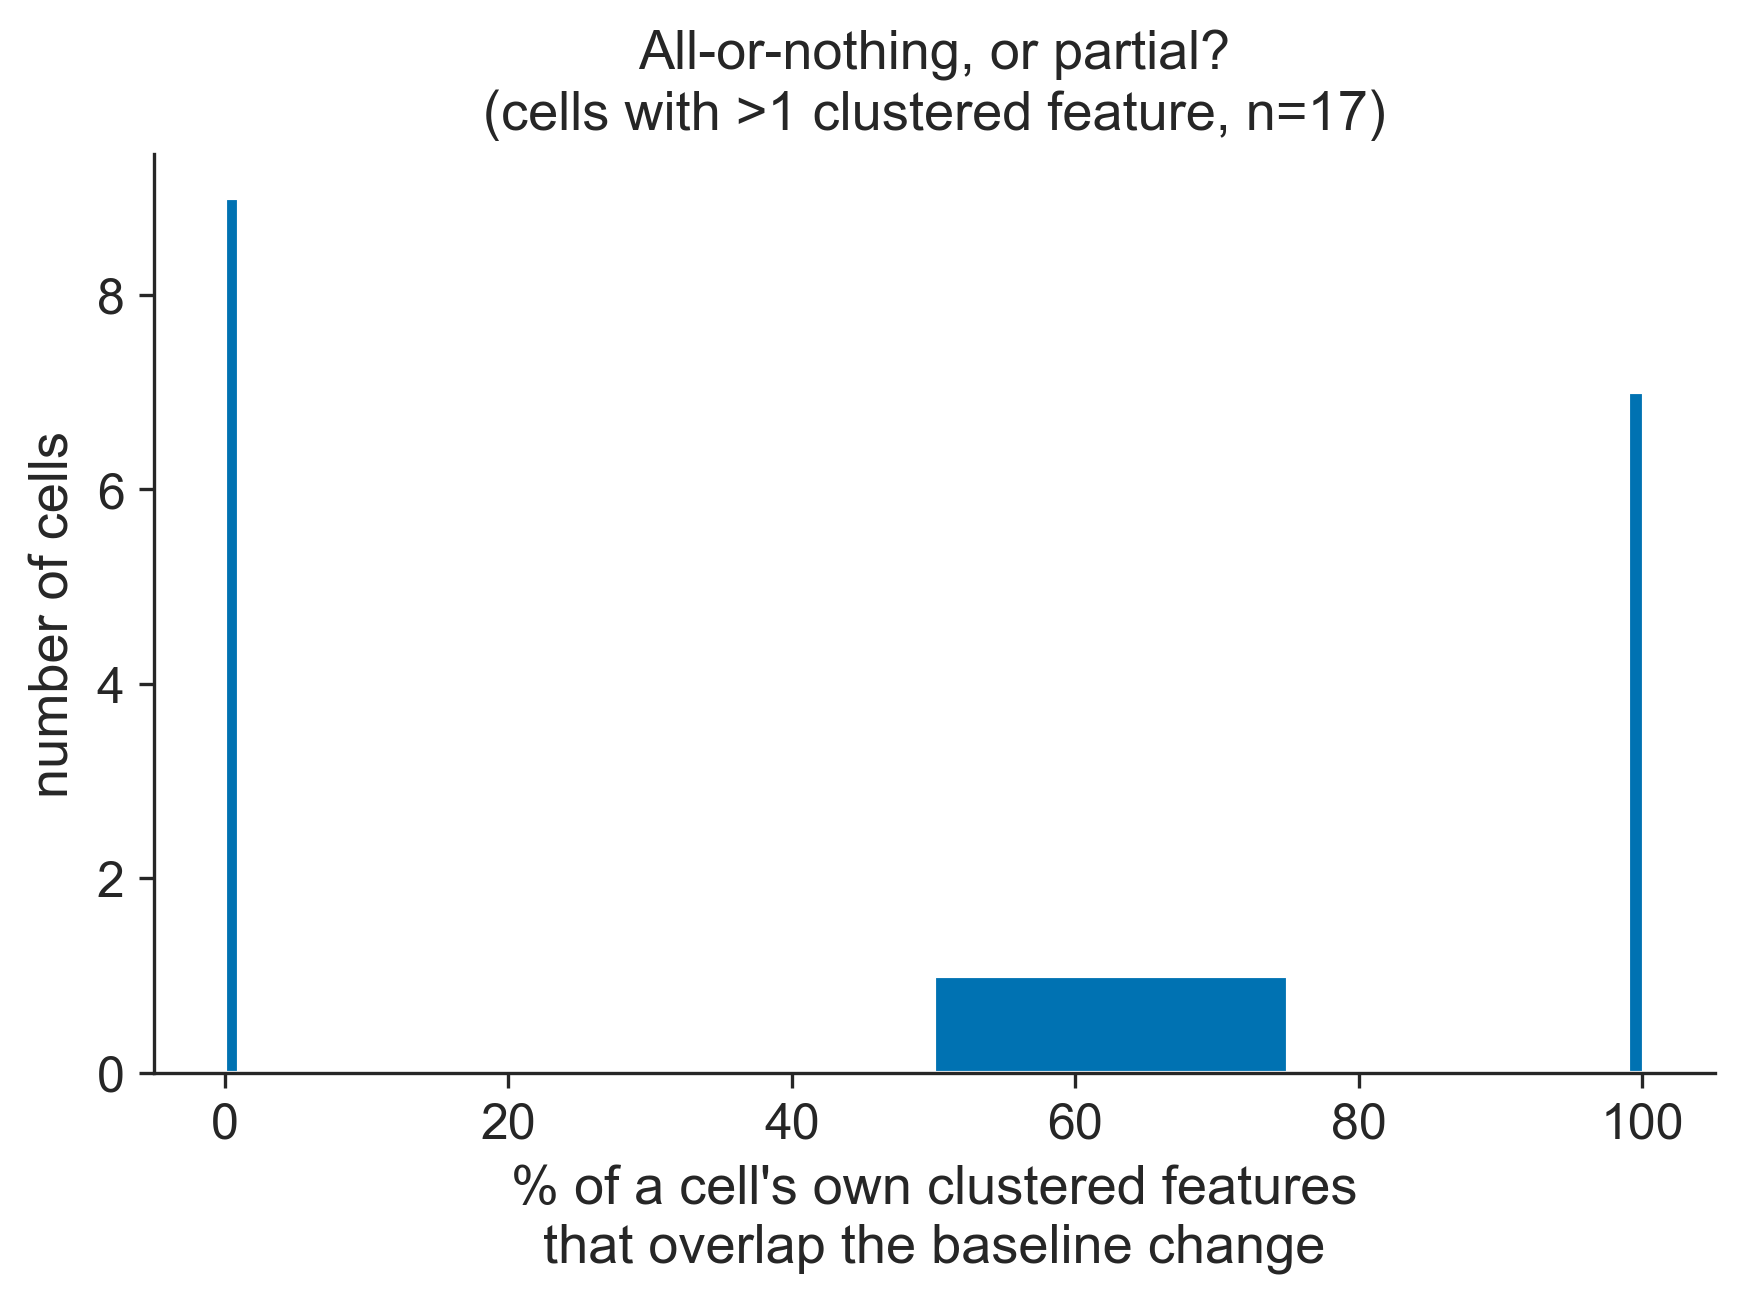

7 / 17 cells with multiple clustered features show ALL of them overlapping the baseline change.
1 / 17 show only SOME of them overlapping.


,cell_id,n_features,n_overlapping,pct_overlapping
0,c1,3,3,100.0
8,c21,3,3,100.0
29,c6,2,2,100.0
13,c27,4,4,100.0
28,c5,5,5,100.0
26,c45,2,2,100.0
5,c19,2,2,100.0
12,c25,3,2,66.7
24,c42,2,0,0.0
25,c44,2,0,0.0


In [10]:
cell_summary = feature_overlap_df.groupby('cell_id').agg(
    n_features=('feature', 'count'),
    n_overlapping=('overlaps_baseline', 'sum'),
).reset_index()
cell_summary['pct_overlapping'] = (cell_summary['n_overlapping'] / cell_summary['n_features'] * 100).round(1)

multi_feature = cell_summary[cell_summary['n_features'] > 1].sort_values('pct_overlapping', ascending=False)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(multi_feature['pct_overlapping'], bins=[0, 1, 25, 50, 75, 99, 100.1],
        color='#0072B2', edgecolor='white')
ax.set_xlabel('% of a cell\'s own clustered features\nthat overlap the baseline change', fontsize=13)
ax.set_ylabel('number of cells', fontsize=13)
ax.set_title(f'All-or-nothing, or partial?\n(cells with >1 clustered feature, n={len(multi_feature)})', fontsize=13)
ax.tick_params(labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'{(multi_feature["pct_overlapping"] == 100).sum()} / {len(multi_feature)} cells with multiple clustered '
      f'features show ALL of them overlapping the baseline change.')
print(f'{((multi_feature["pct_overlapping"] > 0) & (multi_feature["pct_overlapping"] < 100)).sum()} / '
      f'{len(multi_feature)} show only SOME of them overlapping.')
multi_feature

**Putting the three checks together:** peak_amp and peak_width carry most of the effect (71% and 60% of cells with that feature overlap a baseline change), exp_lambda and peak_sharpness about half, exp_const never does. Where a feature overlaps, it usually stays mixed rather than cleanly switching, exp_lambda, inflection_amp, and inflection_time are still mixed every time they overlap, peak_width 7 of 9, peak_sharpness 4 of 6, peak_amp is the one closer to a coin flip (5 of 10). c21 (used as the visual example above) fits that typical pattern, not an exception. And it's not all-or-nothing per cell either: of the 17 cells with more than one clustered feature, 7 show every feature overlapping, 1 shows only some, and 9 show none, so a cell's features don't automatically move together just because it has a real baseline shift.

### Example: c21

What a real overlap actually looks like: the baseline drops, peak amplitude jumps to a new cluster mix at the same moment, and it stays a genuine mix (not a clean switch) afterward.

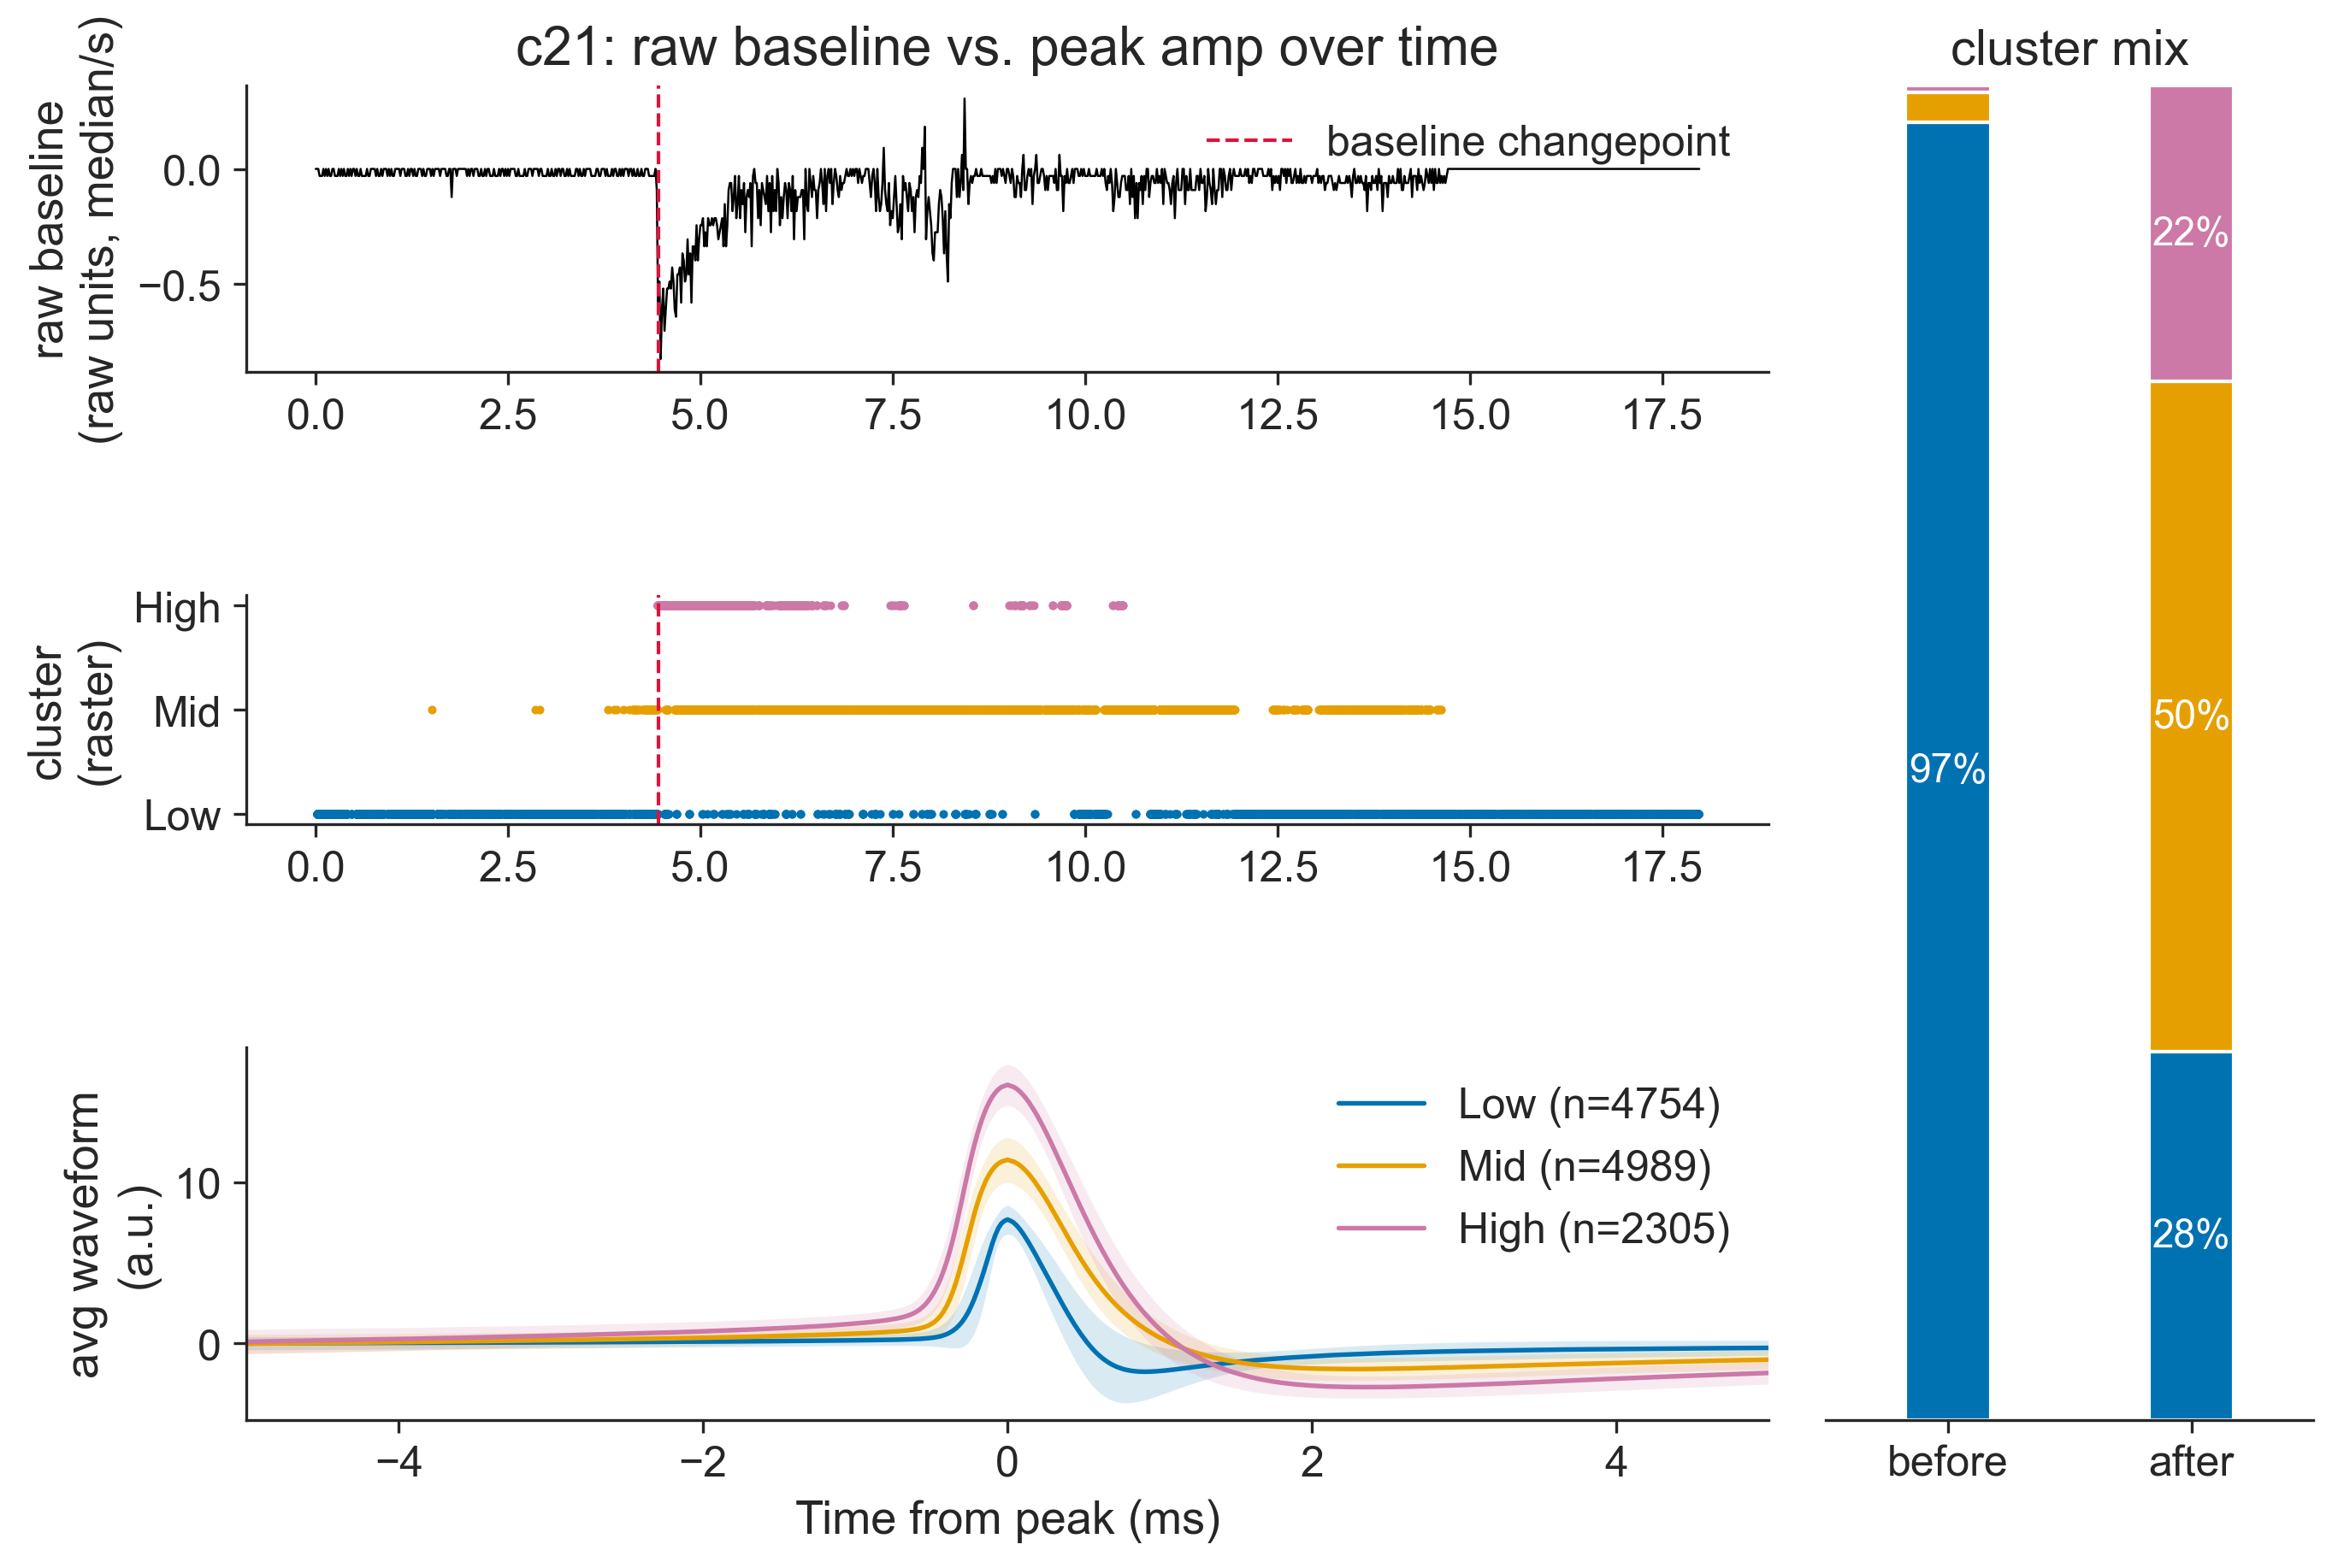

In [11]:
cp = baseline_changepoints['c21'][0]
fig = plot_baseline_vs_cluster_example(21, 'peak_amp_cluster', cp, split_label='baseline changepoint')
plt.show()

### Every cell with a waveform shift but no baseline changepoint

9 cells qualify. For each, show its baseline (left) against the raster of whichever clustered feature has the cleanest (fewest-changepoint) shift (right), so they're comparable side by side.

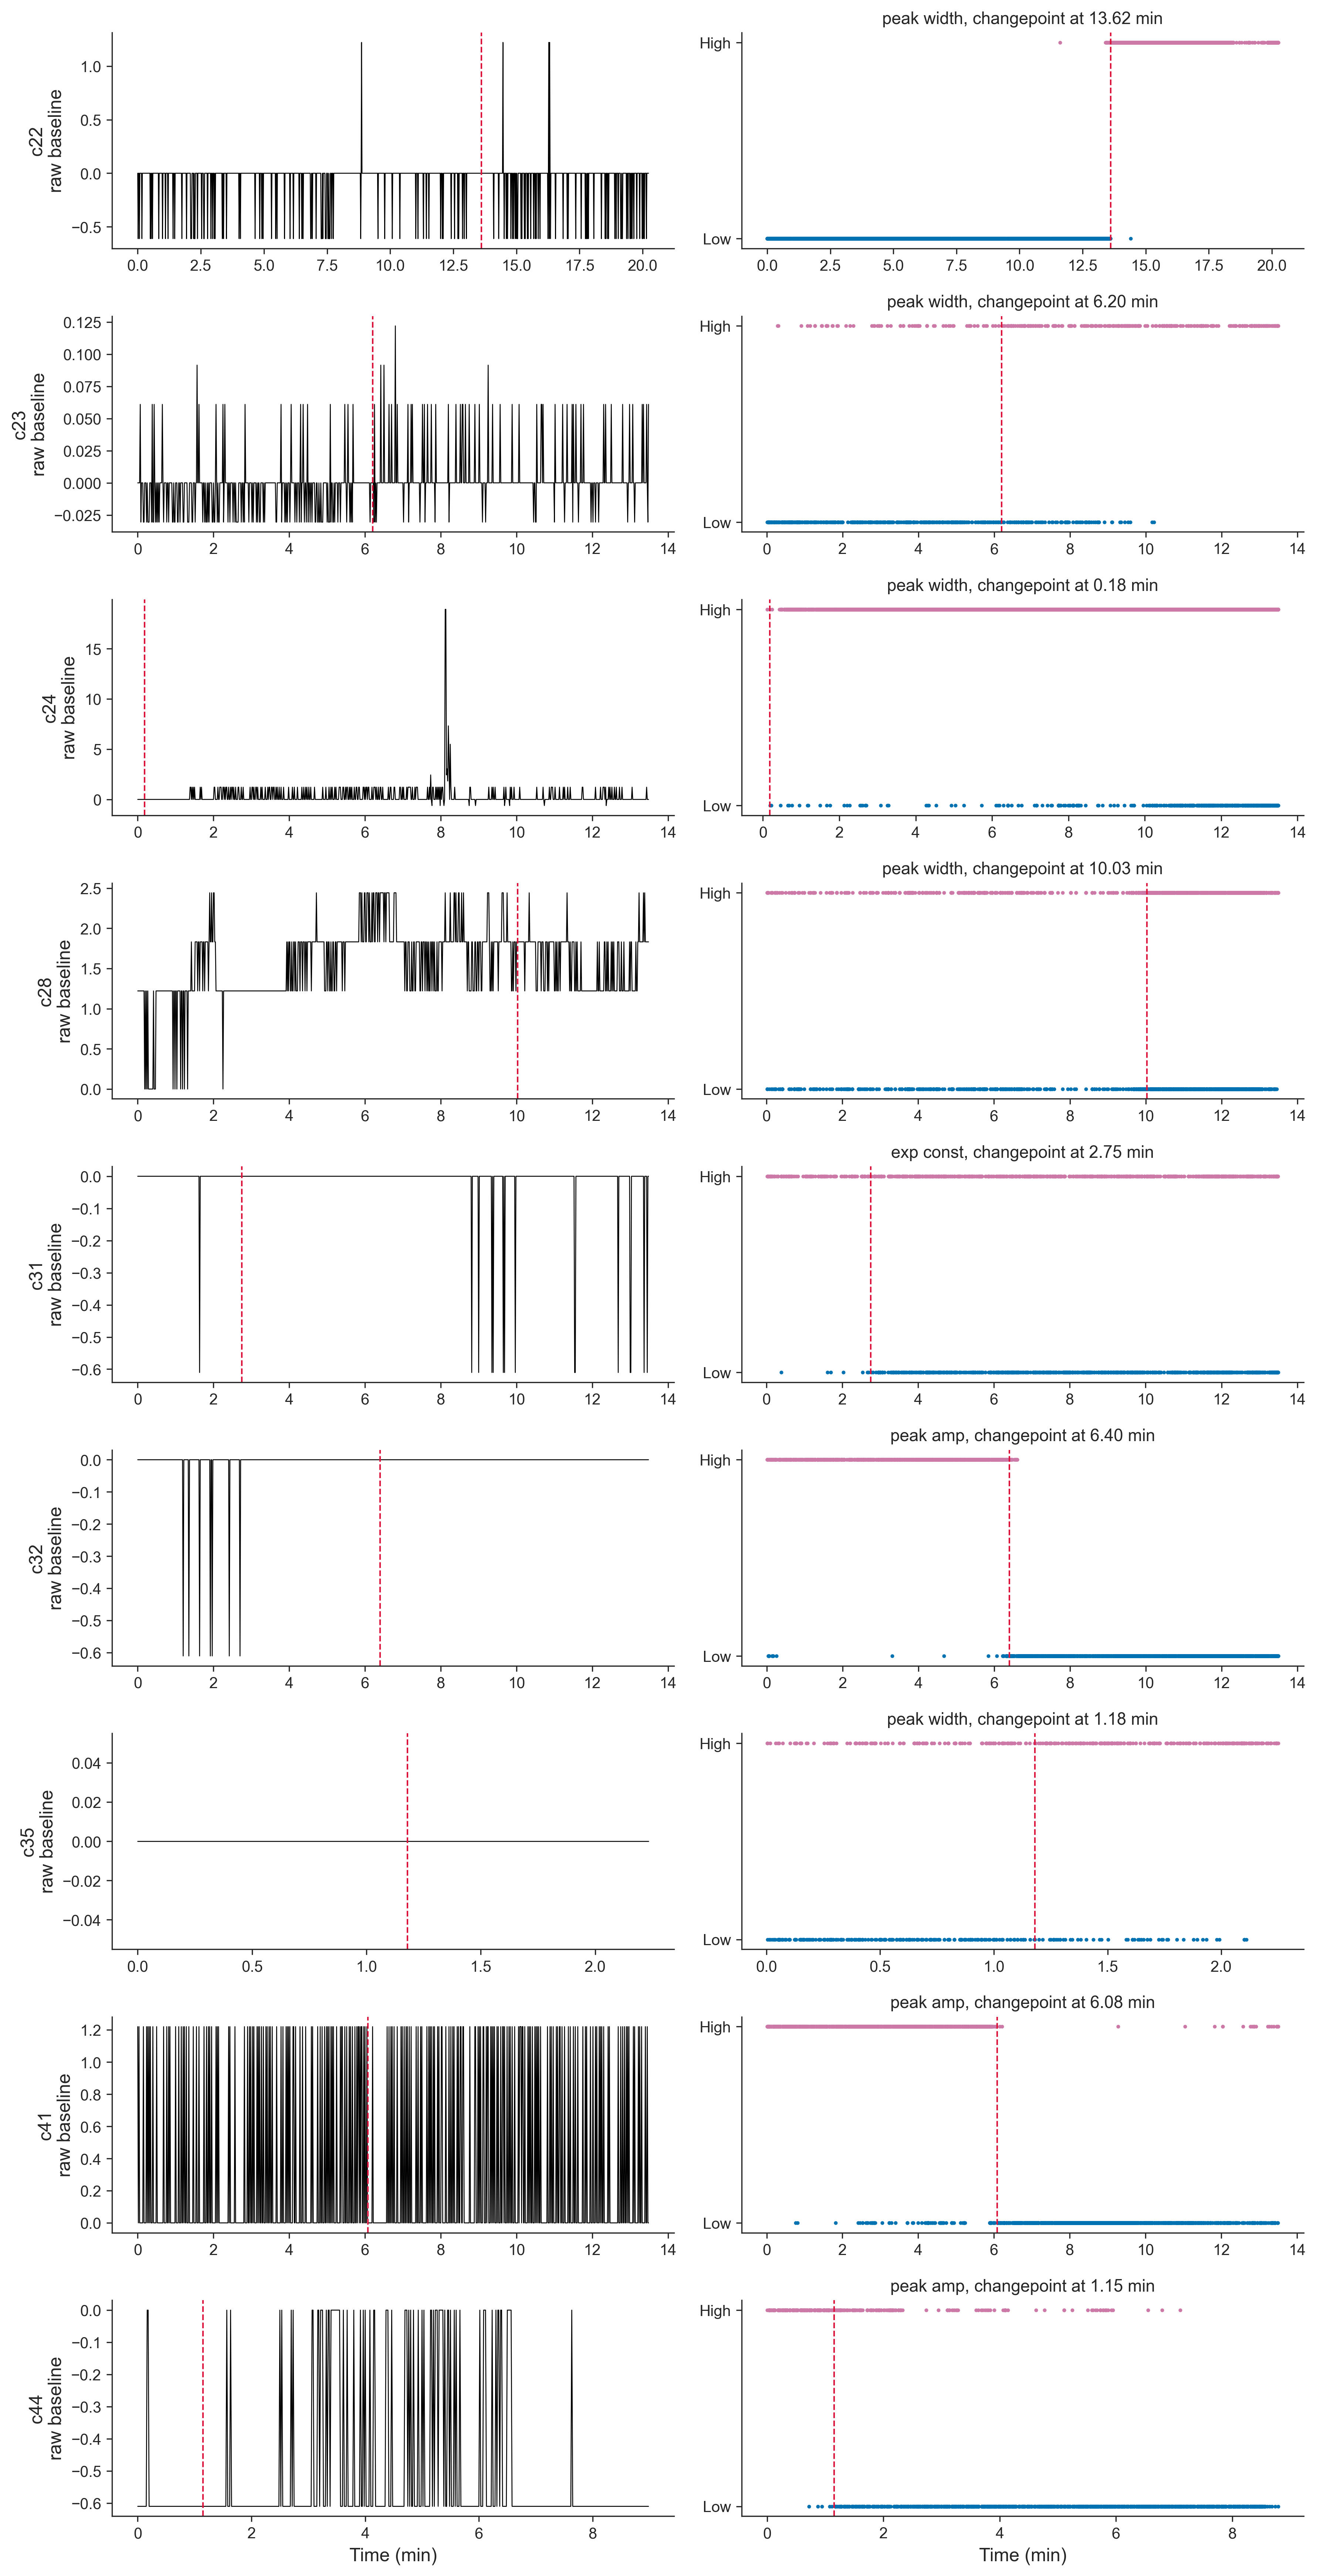

In [12]:
no_baseline_candidates = []
for cid, feats in cluster_changepoints.items():
    if len(baseline_changepoints.get(cid, [])) == 0:
        feat, cps = min(feats.items(), key=lambda kv: len(kv[1]))
        no_baseline_candidates.append((cid, feat, cps[0]))
no_baseline_candidates.sort(key=lambda x: int(x[0][1:]))

fig, axes = plt.subplots(len(no_baseline_candidates), 2, figsize=(12, 2.6 * len(no_baseline_candidates)))

for row, (cid, feat, cp) in enumerate(no_baseline_candidates):
    cell_num = int(cid[1:])
    t_min, baseline = baselines[cell_num]
    df = load_cluster_df(cell_num)
    spk_min = df['spk_times_ms'].to_numpy() / 60000.0
    clusters = df[feat].to_numpy()

    ax_b, ax_r = axes[row, 0], axes[row, 1]
    ax_b.plot(t_min, baseline, color='black', lw=0.6)
    ax_b.axvline(cp, color='crimson', ls='--', lw=1)
    ax_b.set_ylabel(f'{cid}\nraw baseline', fontsize=12)
    ax_b.tick_params(labelsize=10)

    for lab in ['low', 'mid', 'high']:
        mask = clusters == lab
        ax_r.scatter(spk_min[mask], [lab.capitalize()] * mask.sum(), s=2, color=CLUST_COLORS[lab])
    ax_r.axvline(cp, color='crimson', ls='--', lw=1)
    ax_r.set_title(f'{strip_cluster(feat)}, changepoint at {cp:.2f} min', fontsize=11)
    ax_r.tick_params(labelsize=10)

    sns.despine(ax=ax_b)
    sns.despine(ax=ax_r)

axes[-1, 0].set_xlabel('Time (min)', fontsize=12)
axes[-1, 1].set_xlabel('Time (min)', fontsize=12)
plt.tight_layout()
plt.show()

### Counter-example: c32, a waveform shift with no baseline shift

Of the 9 above, c32 is the cleanest: its `peak_amp` cluster flips almost completely at ~6.4 min (97.5% High before, 98.9% Low after), and the baseline noise it does have is confined to the first 3 minutes, well before that changepoint. Its baseline never earns a changepoint at all, again because it's degenerate (`typical_step = 0`, flat/silent aside from occasional spikes) rather than because we checked and found nothing.

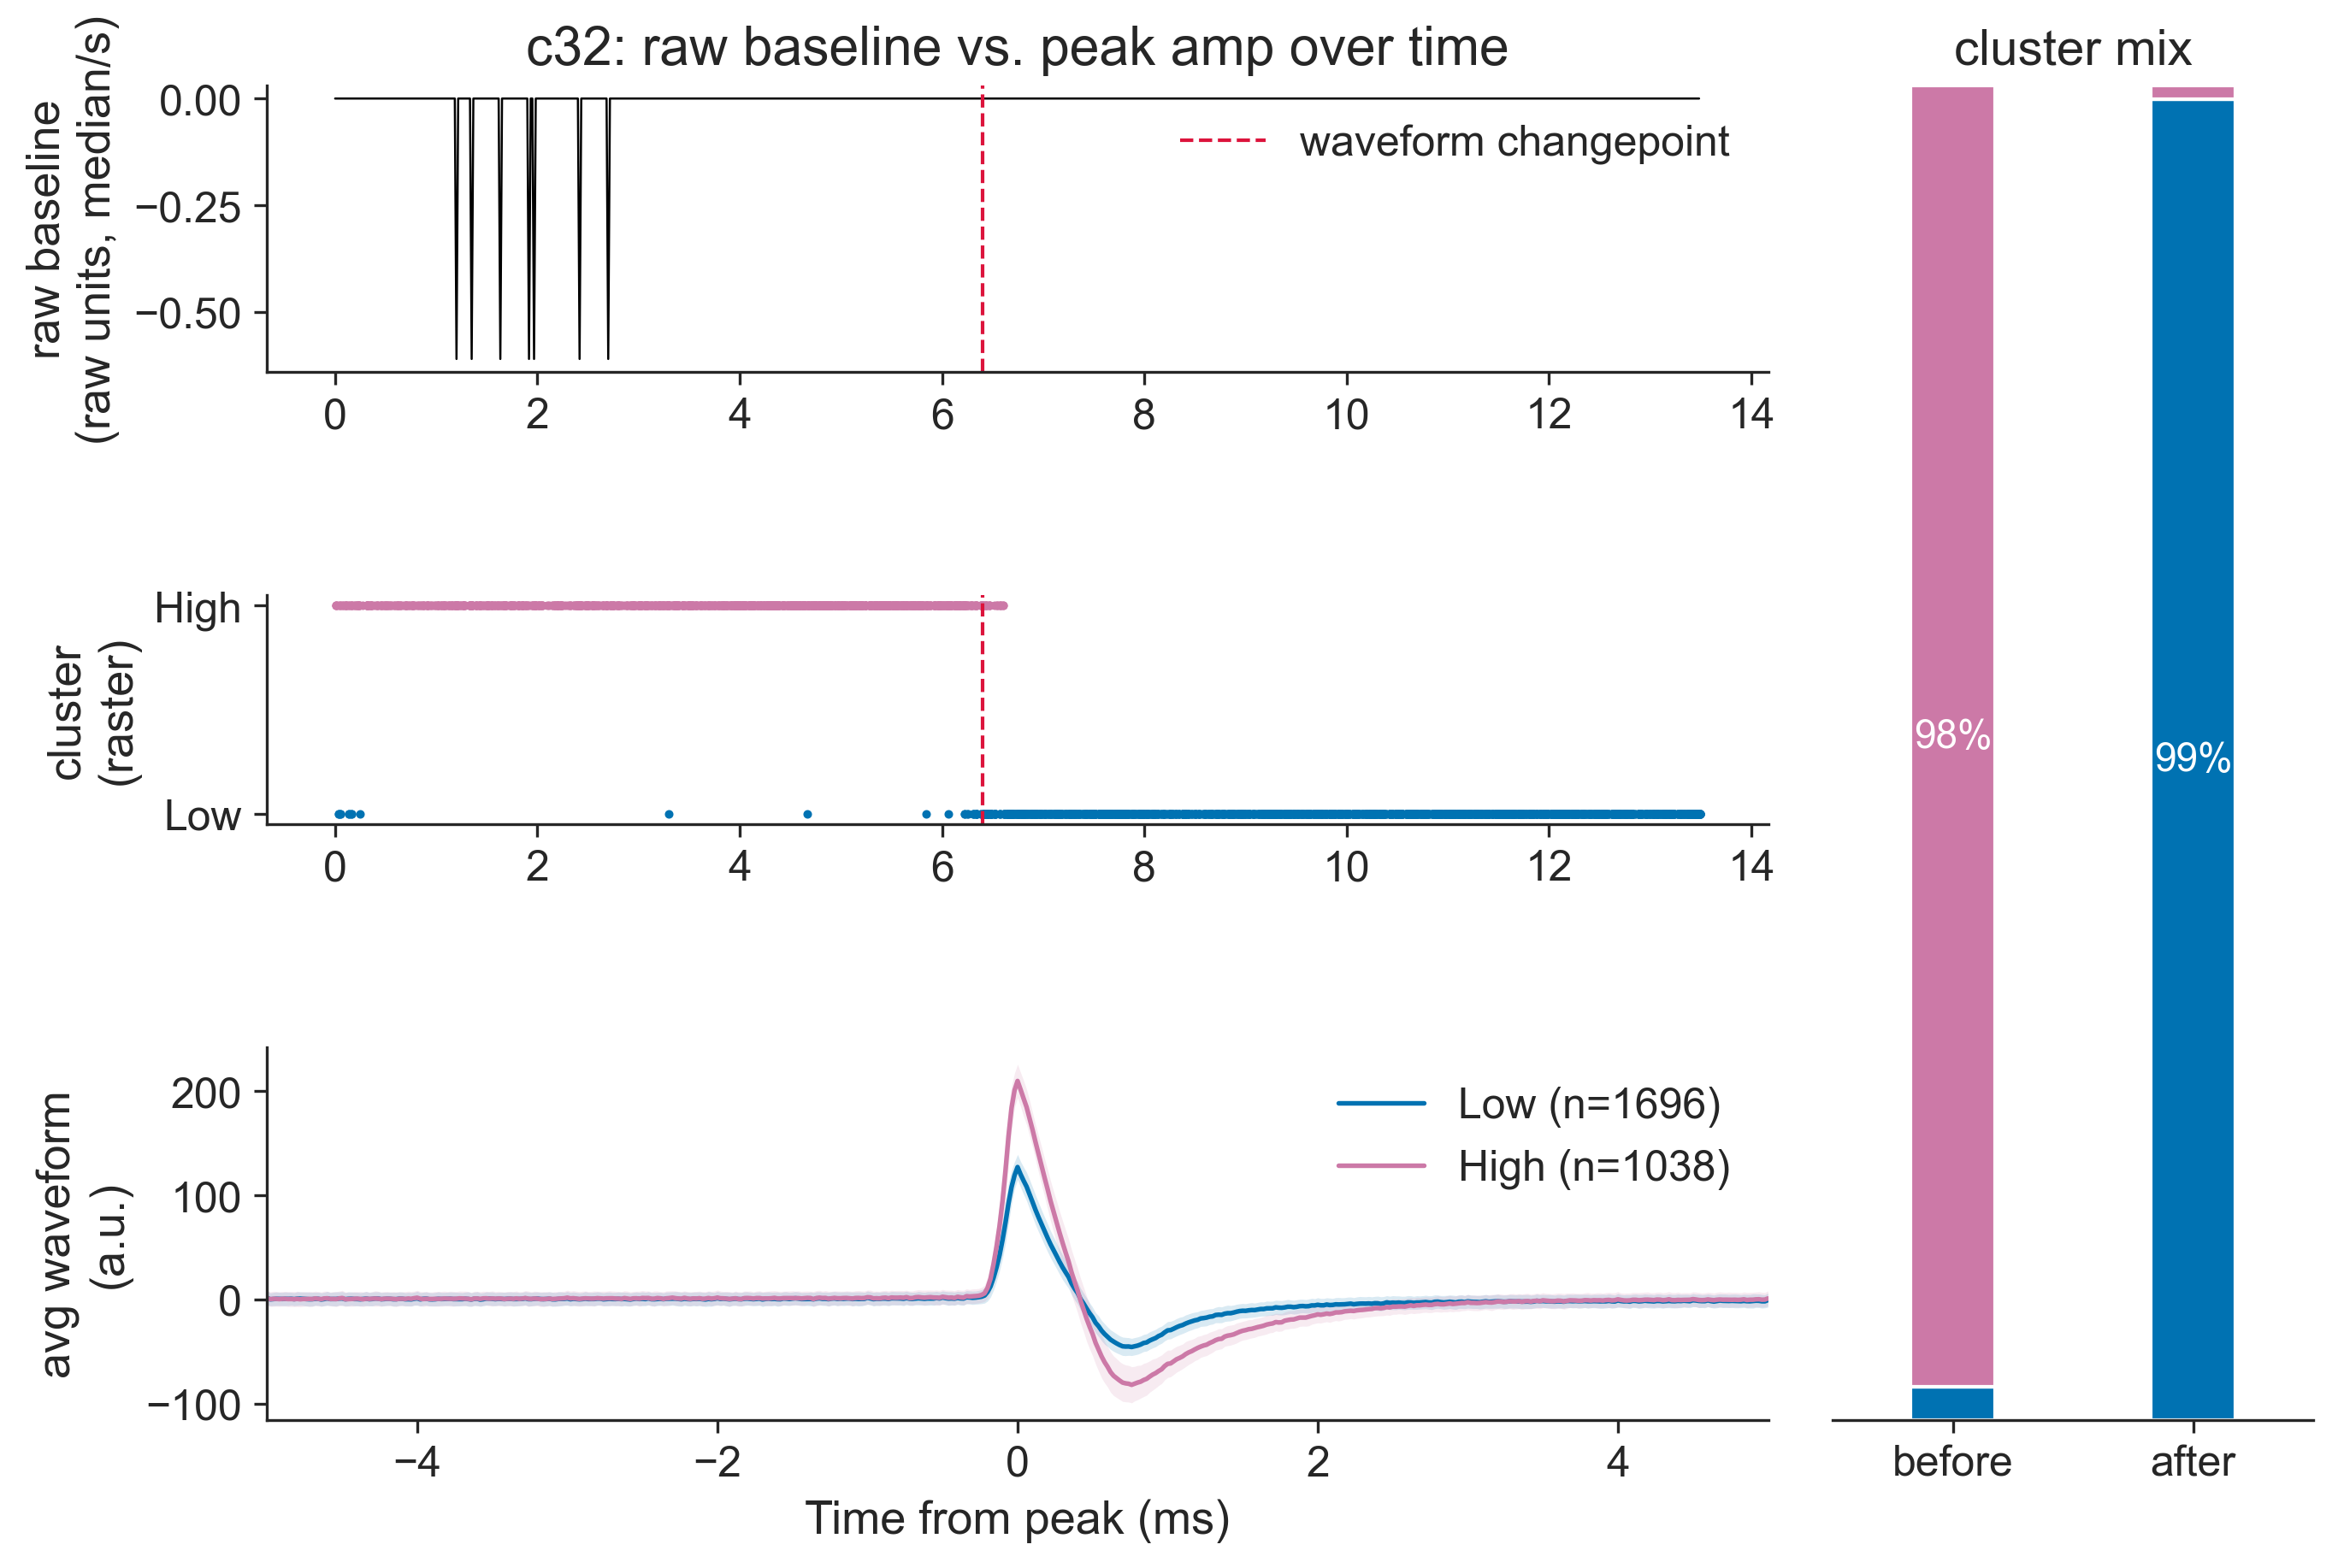

In [13]:
cp = cluster_changepoints['c32']['peak_amp_cluster'][0]
fig = plot_baseline_vs_cluster_example(32, 'peak_amp_cluster', cp, split_label='waveform changepoint')
plt.show()

Two more from the list above, full detail:

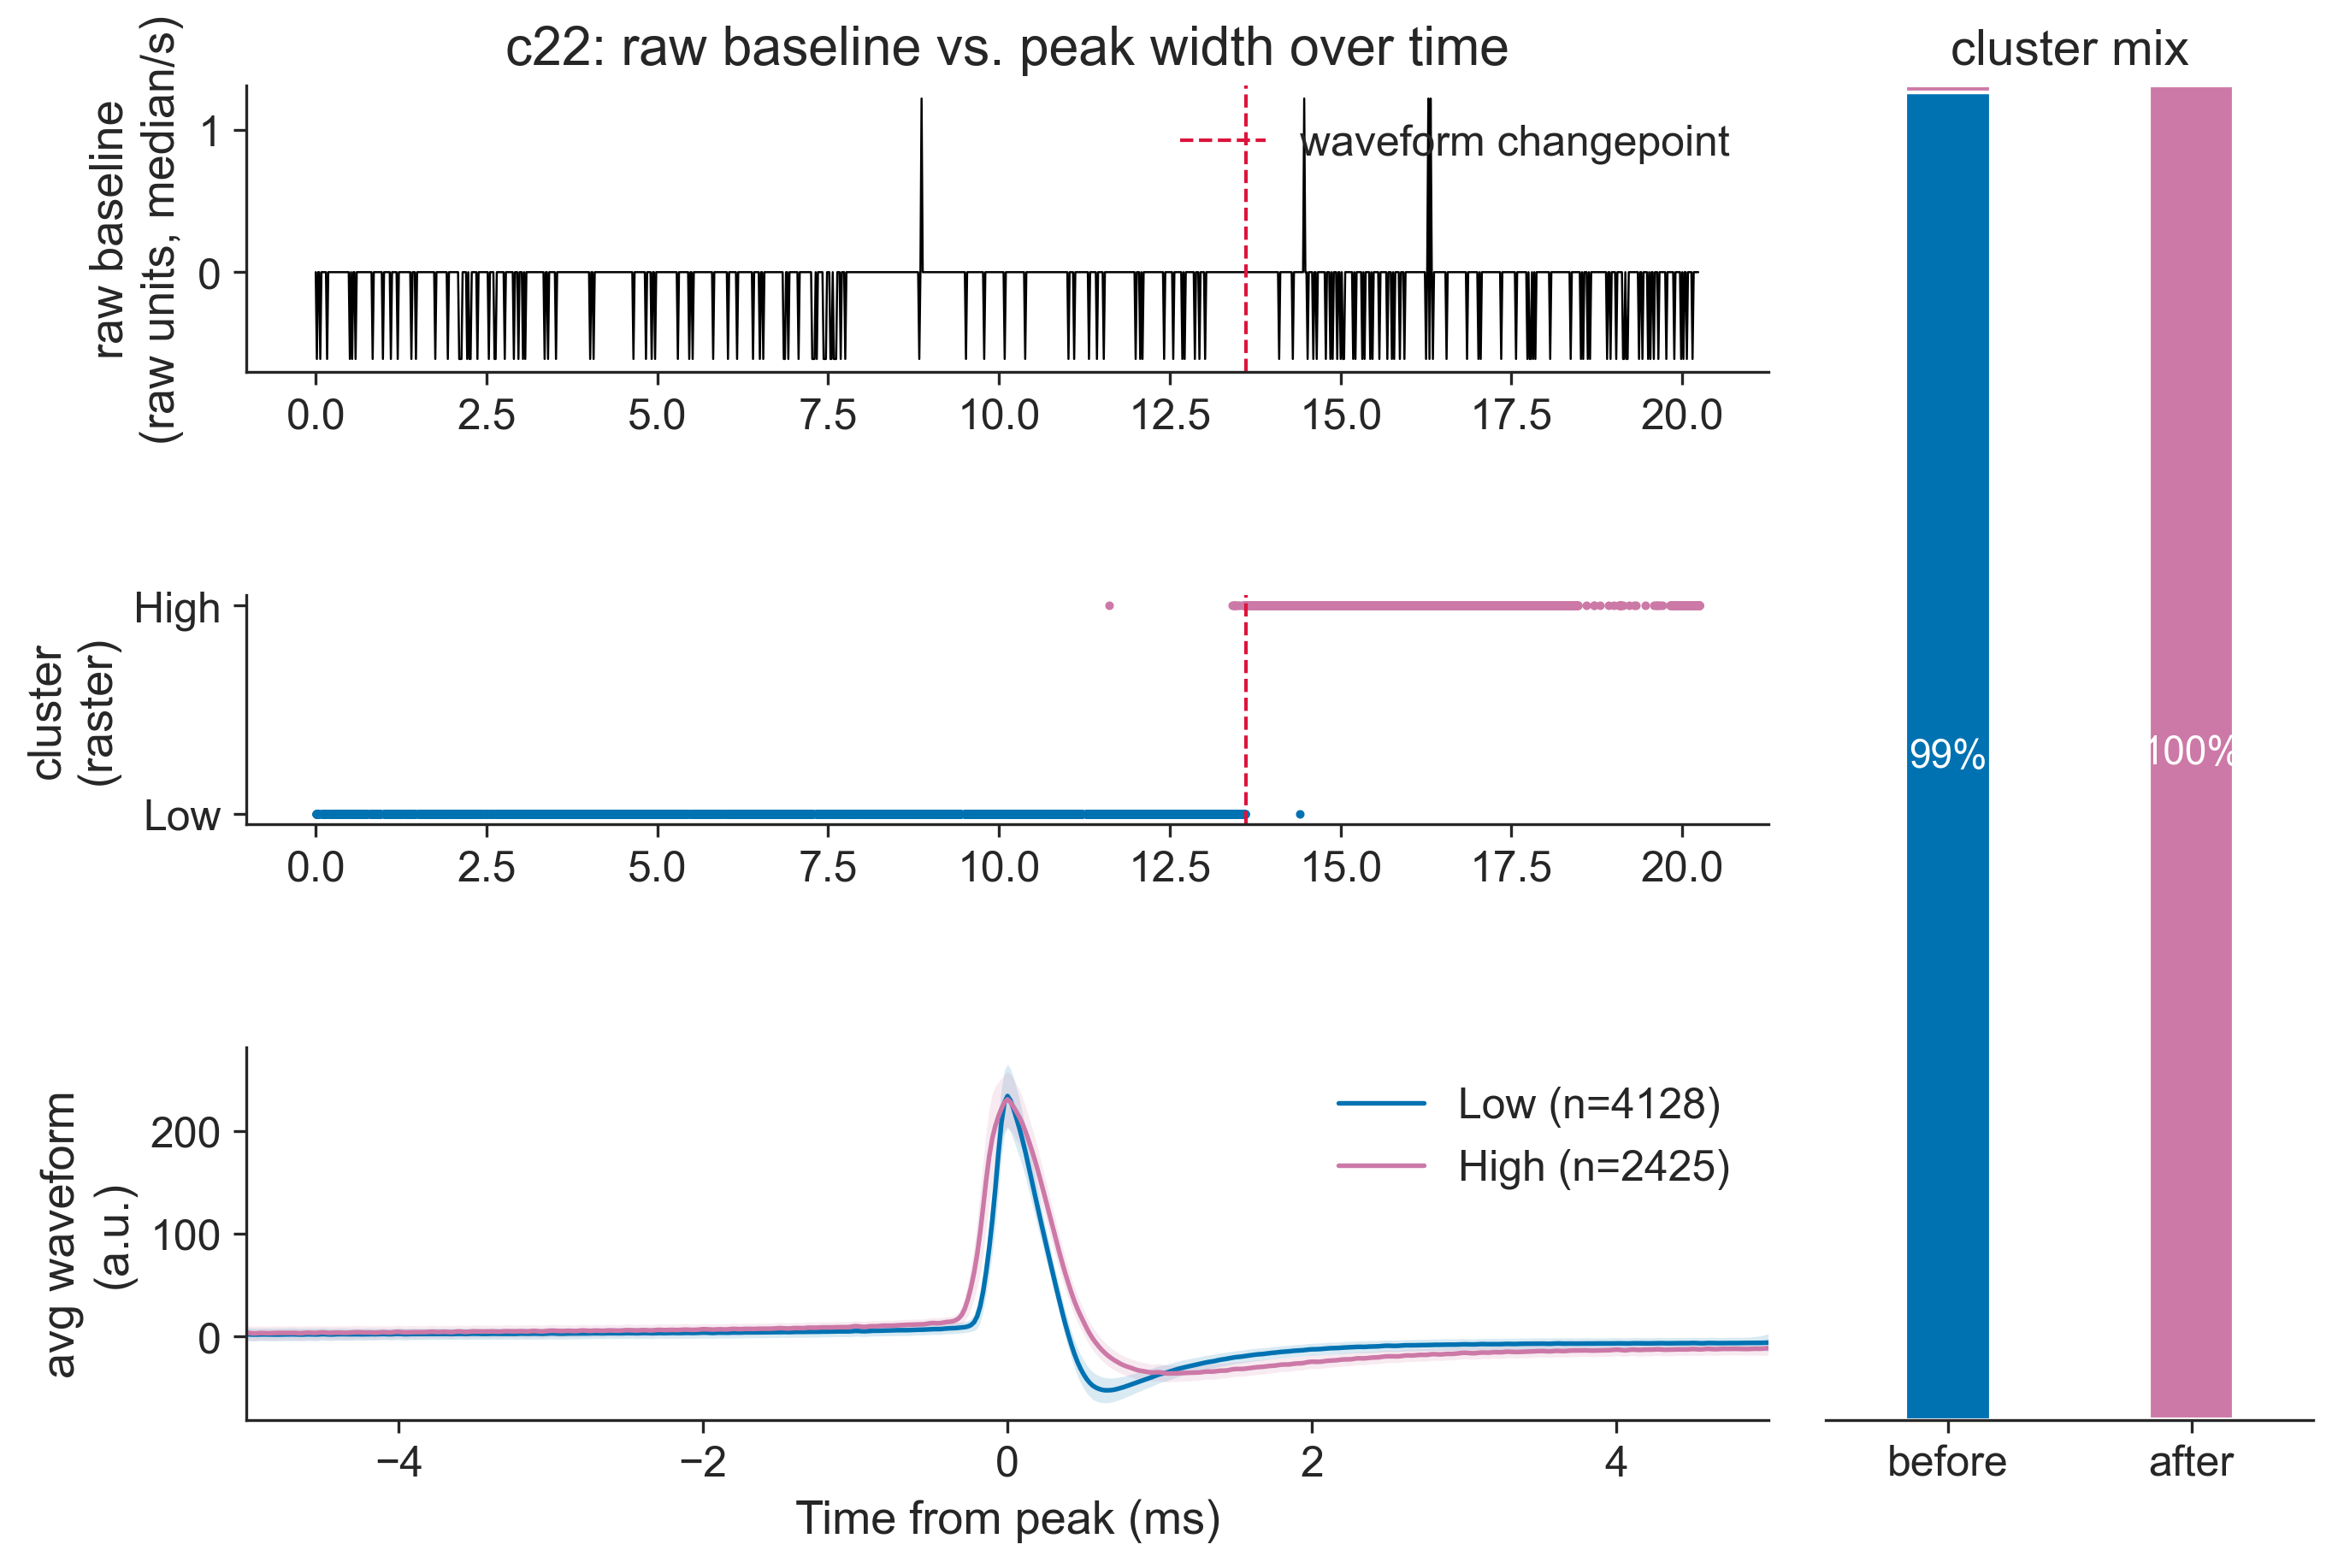

In [14]:
cp = cluster_changepoints['c22']['peak_width_cluster'][0]
fig = plot_baseline_vs_cluster_example(22, 'peak_width_cluster', cp, split_label='waveform changepoint')
plt.show()

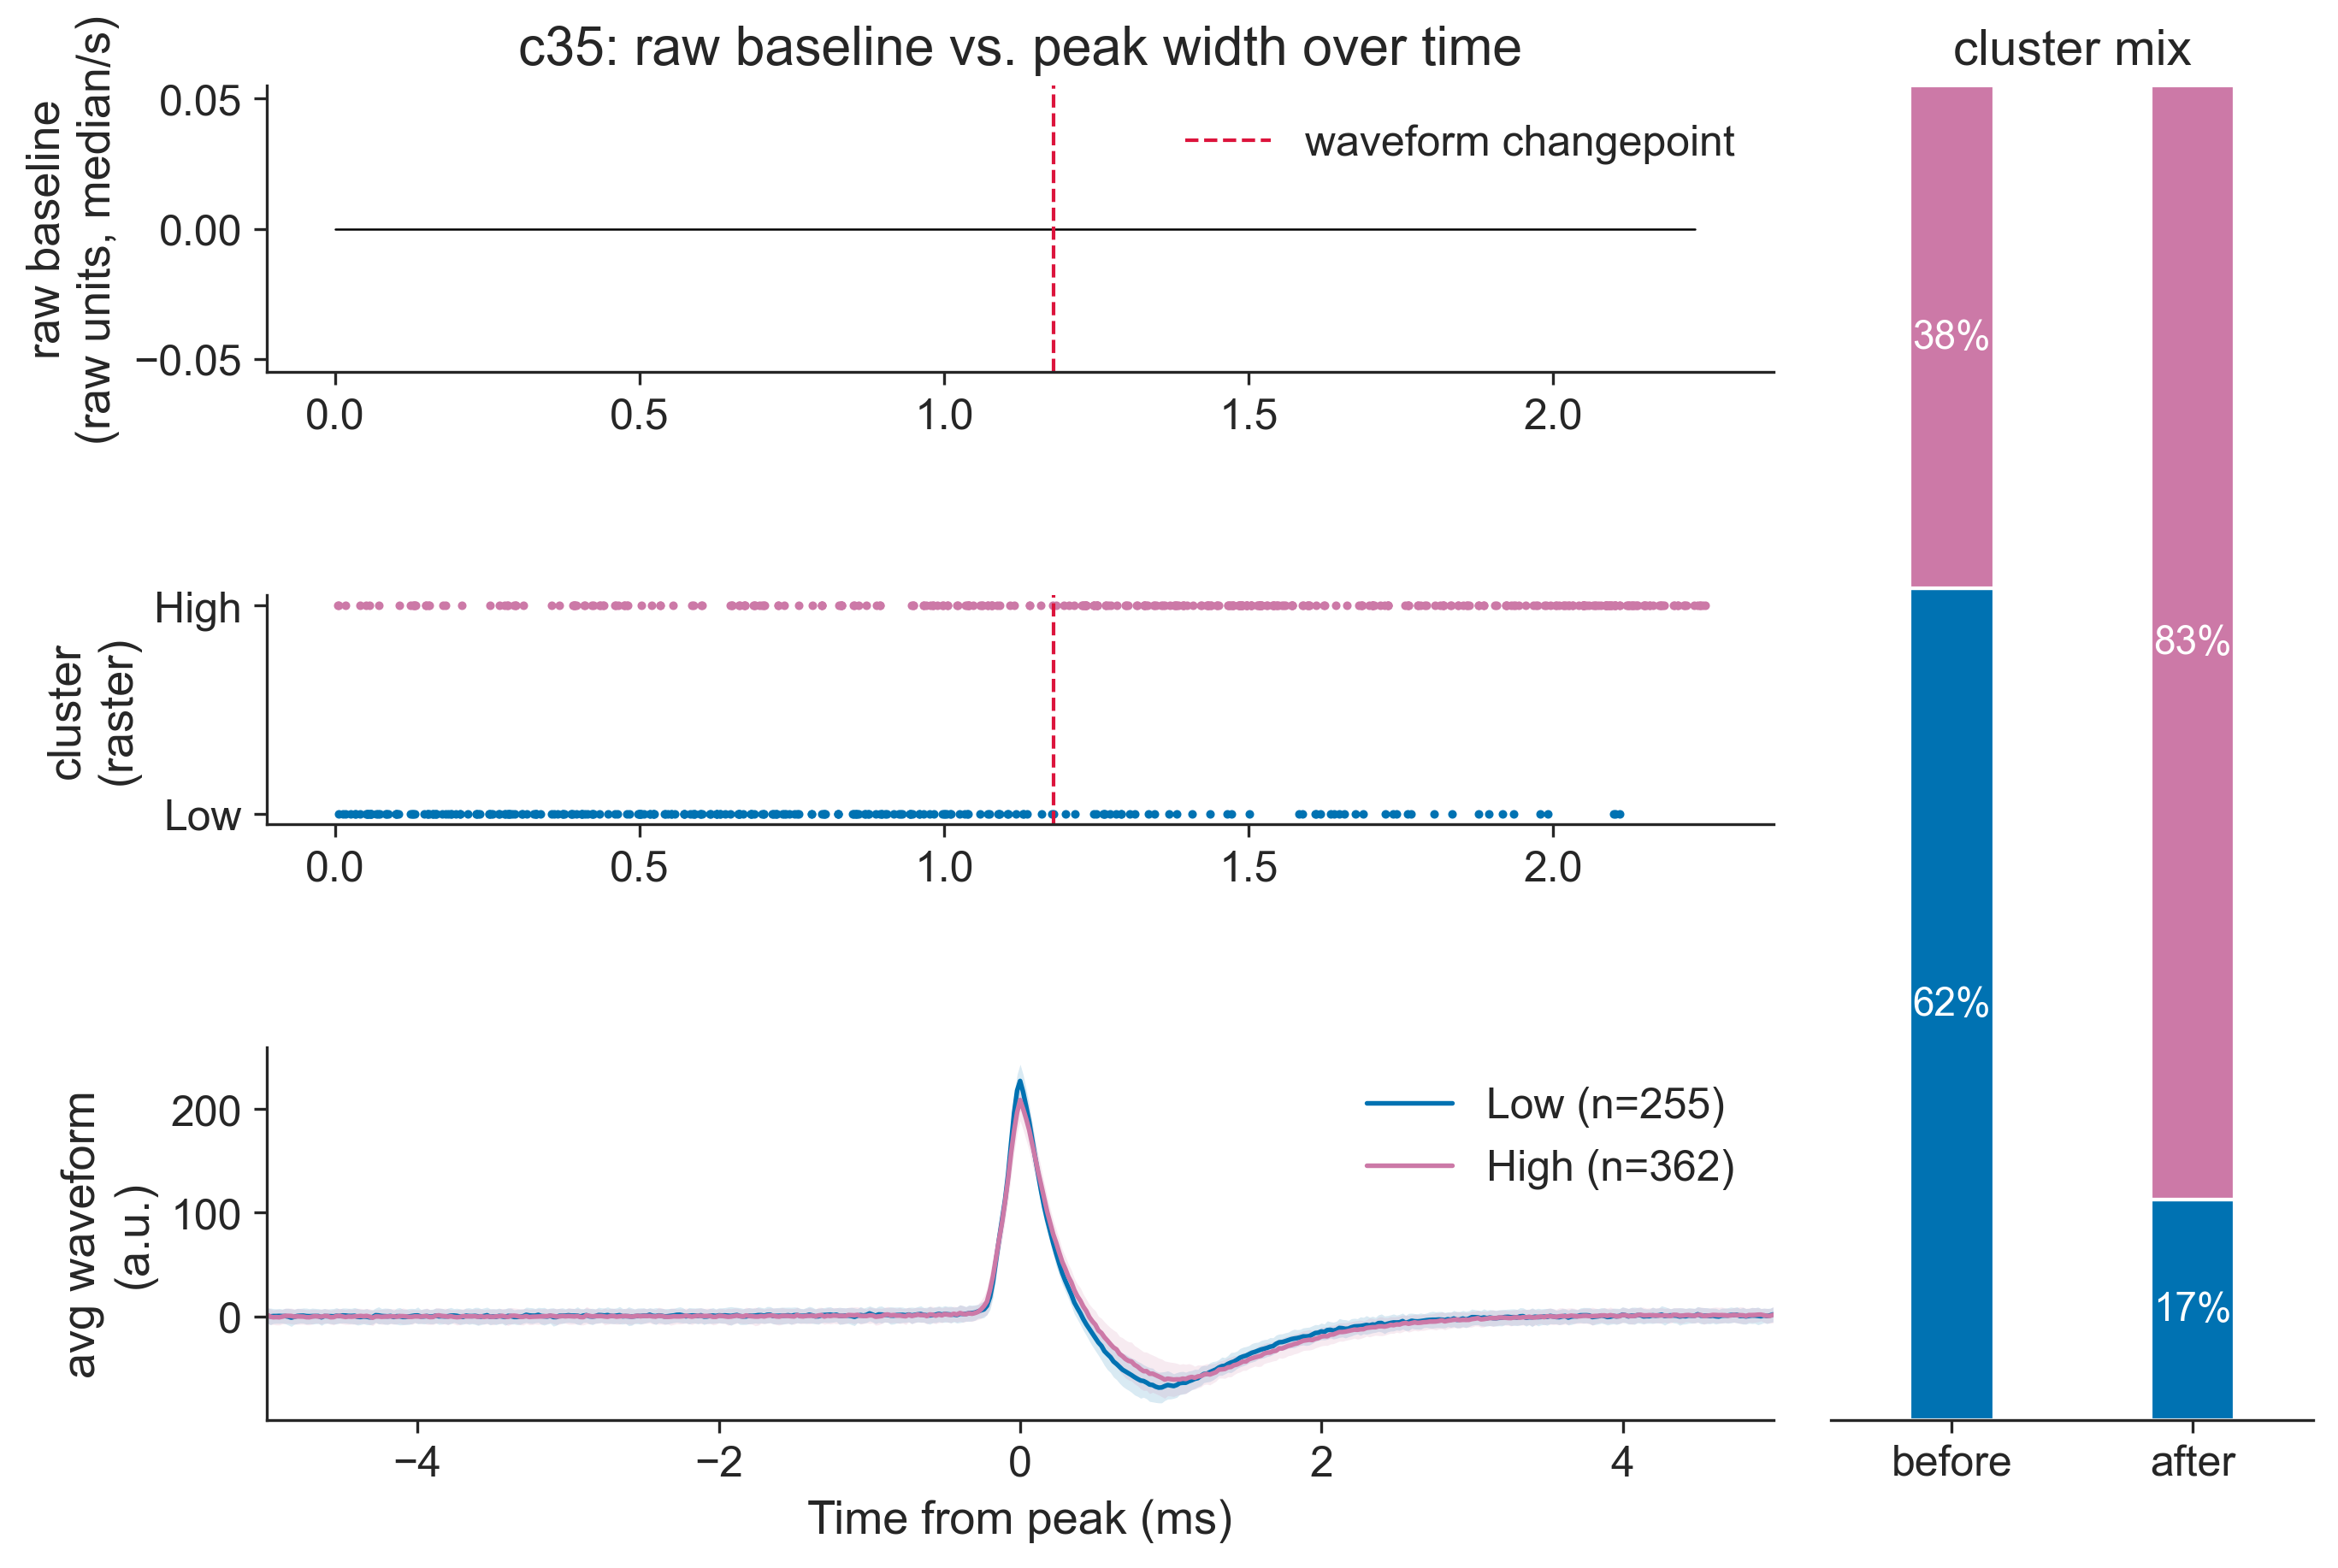

In [15]:
cp = cluster_changepoints['c35']['peak_width_cluster'][0]
fig = plot_baseline_vs_cluster_example(35, 'peak_width_cluster', cp, split_label='waveform changepoint')
plt.show()

### All 43 cells, colored by the validated finding

PELT alone isn't a good "is this cell real" flag, it found a changepoint in 28 of 29 usable cells, most of that is just noise. The meaningful flag is the one actually tested above: does a baseline changepoint overlap a waveform-shape changepoint. That's what's colored below, not raw PELT output.

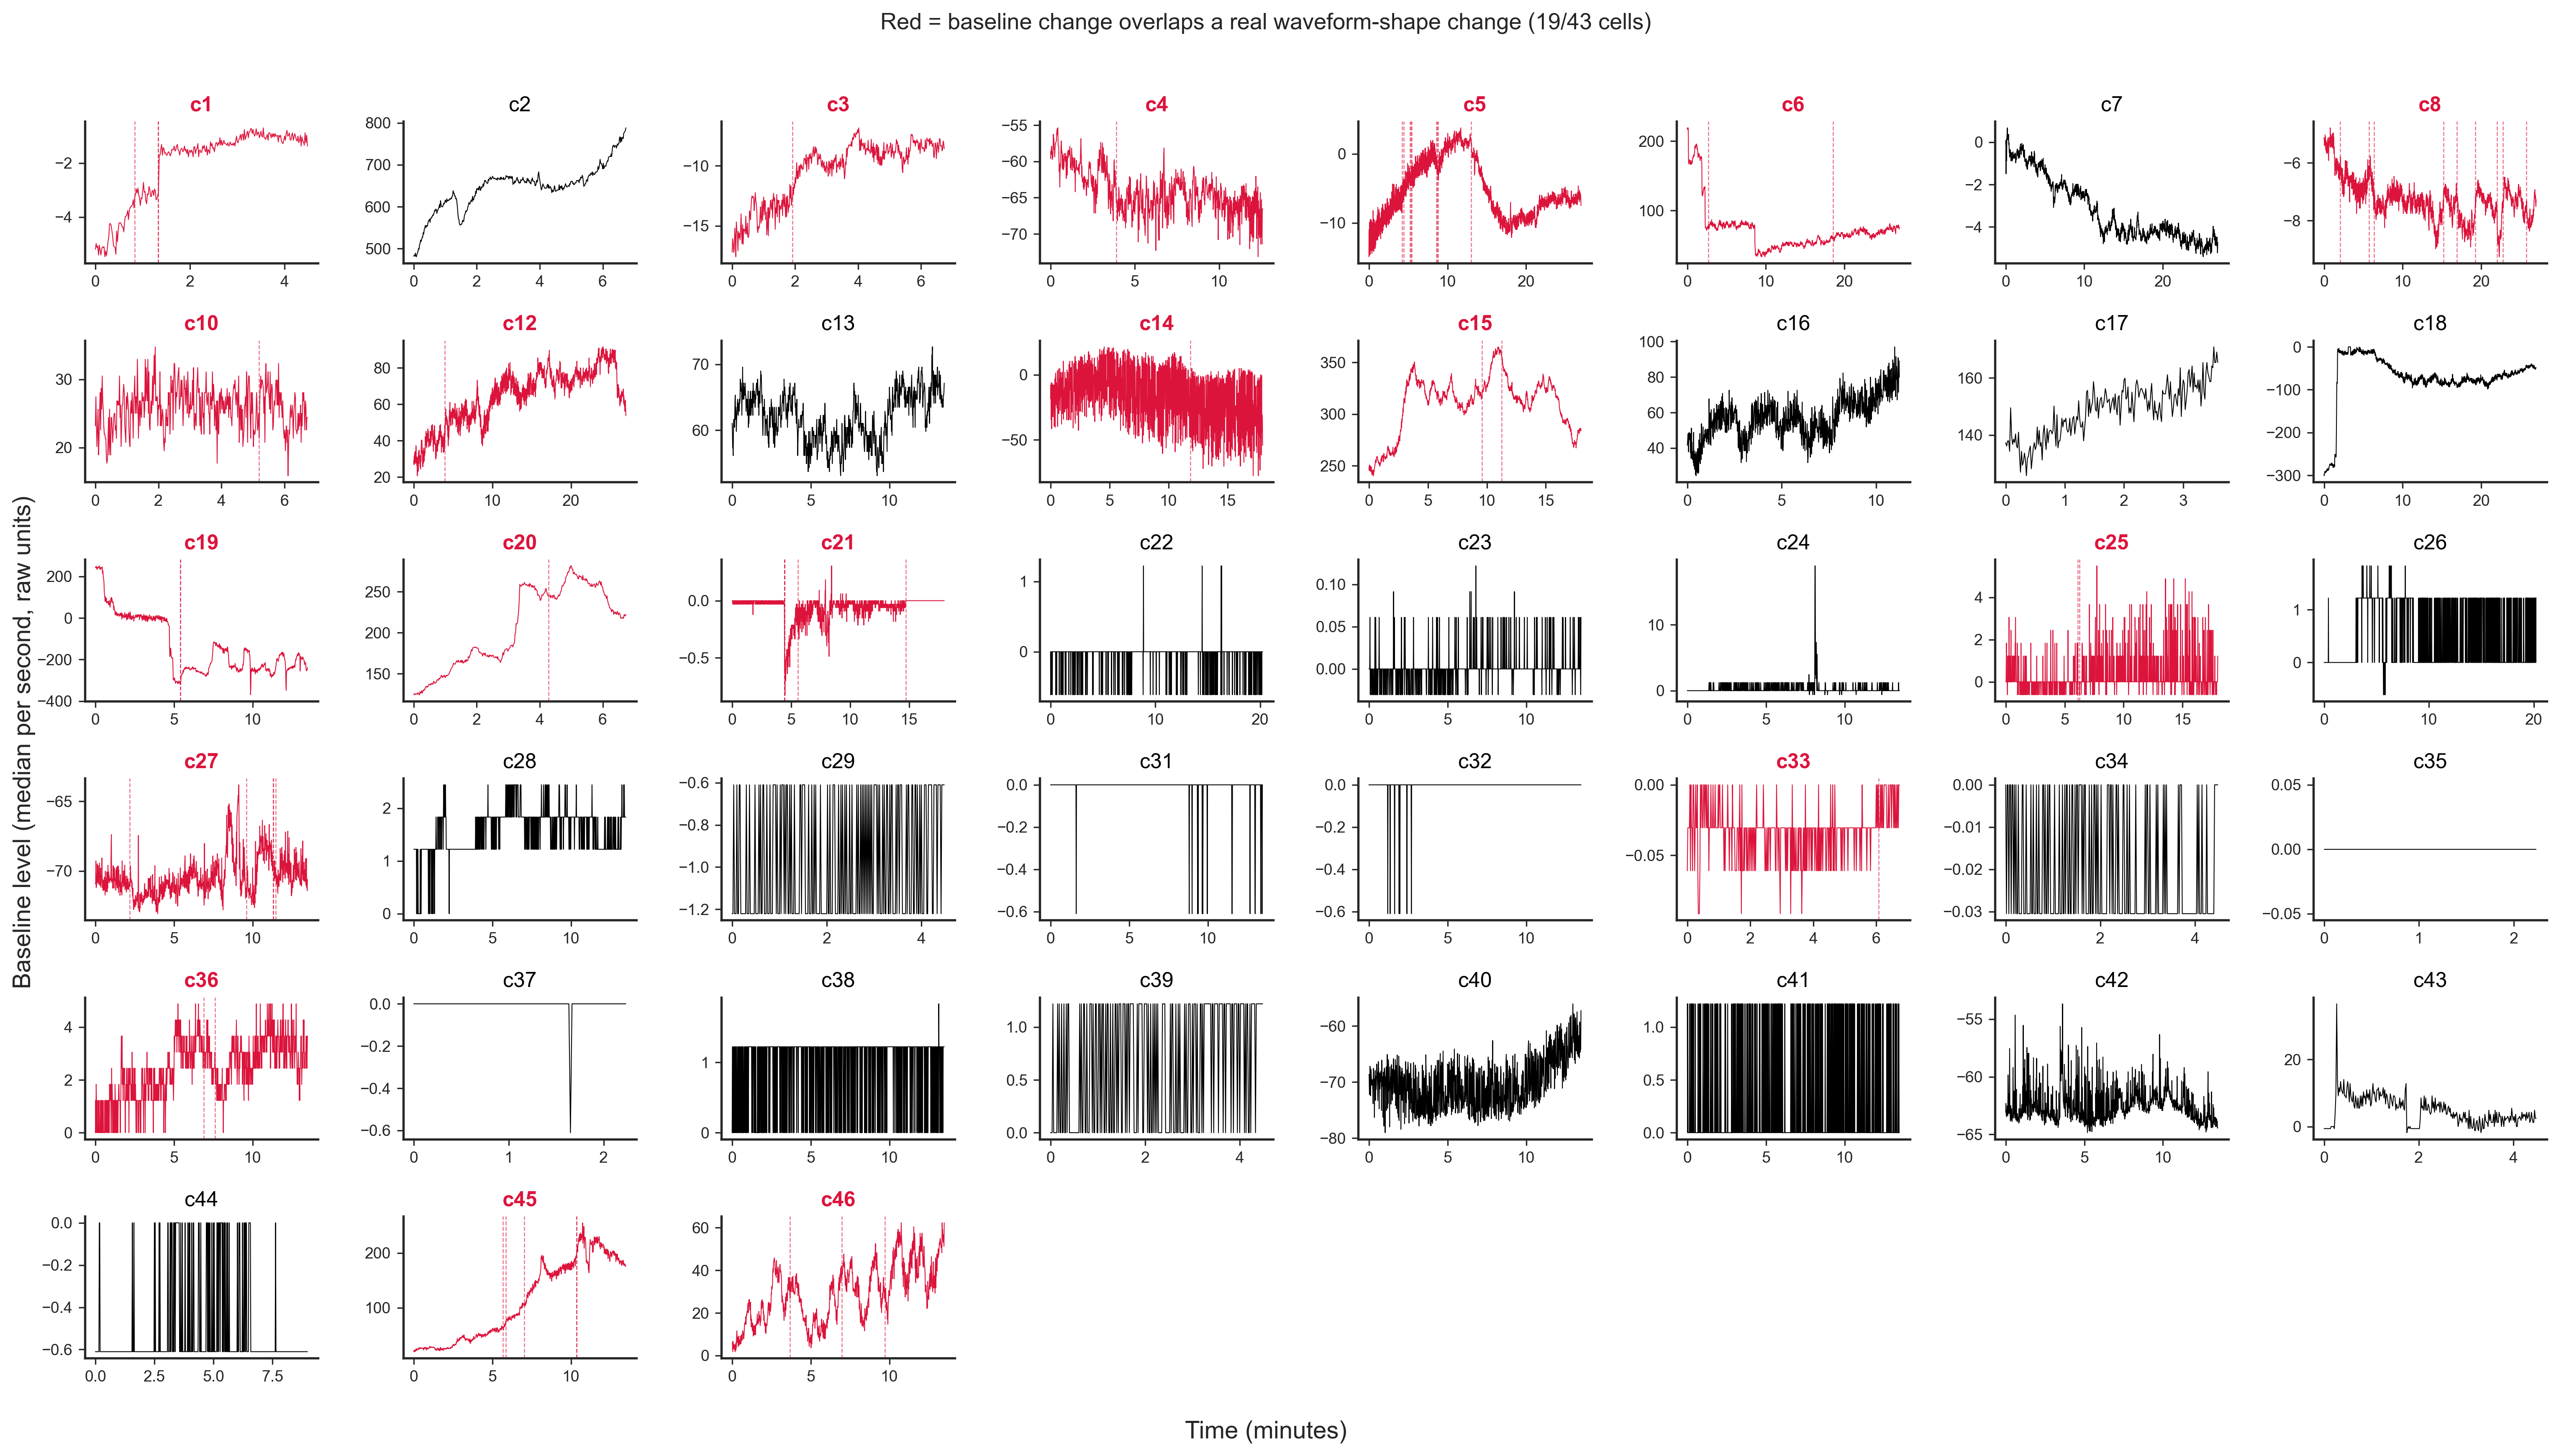

In [16]:
validated_cells = set(feature_overlap_df.loc[feature_overlap_df['overlaps_baseline'], 'cell_id'])

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 1.9))
axes = axes.flatten()

for ax, cell_num in zip(axes, cell_nums):
    cid = f'c{cell_num}'
    t_min, baseline = baselines[cell_num]
    flagged = cid in validated_cells
    ax.plot(t_min, baseline, color='crimson' if flagged else 'black', lw=0.5)
    if flagged:
        for cps in cluster_changepoints.get(cid, {}).values():
            for cp in cps:
                if any(abs(cp - bcp) <= OVERLAP_TOL_MIN for bcp in baseline_changepoints.get(cid, [])):
                    ax.axvline(cp, color='crimson', ls='--', lw=0.6, alpha=0.6)
    ax.set_title(cid, fontsize=12, color='crimson' if flagged else 'black',
                 fontweight='bold' if flagged else 'normal')
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)

for ax in axes[n:]:
    ax.axis('off')

fig.supxlabel('Time (minutes)', fontsize=14)
fig.supylabel('Baseline level (median per second, raw units)', fontsize=14)
fig.suptitle(f'Red = baseline change overlaps a real waveform-shape change ({len(validated_cells)}/43 cells)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
**Data used:** raw, unfiltered `c{N}_patch_ch1.bin` recordings for all 43 spe-1 cells, obtained from the lab's original recording archive and placed in `raw_patch_recordings/` alongside the existing `filt_patch_recordings/` used elsewhere in the pipeline. These are the true pre-processing recordings - no bandpass filter has been applied, so a real sustained shift in resting level would appear directly, rather than as the brief filtered echo a shift becomes after the 10 Hz highpass used everywhere else in the paper.